<a href="https://colab.research.google.com/github/sitahlango-maker/Financial_Inclusion/blob/main/cleanfinancialinclusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing Basic Liberaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imports the pandas library for data handling and analysis.
import pandas as pd

In [2]:
# Loads the Kenya survey data file from the public GitHub repository.
df_ken = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Kenya.csv')

# Loads the Tanzania survey data file from the public GitHub repository.
df_tza = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Tanzania.csv')

# Loads the Uganda survey data file from the public GitHub repository.
df_uga = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Uganda.csv')

In [3]:
# Prints the number of rows and columns for each country’s survey file to confirm successful loading.
print("Kenya shape:", df_ken.shape)
print("Tanzania shape:", df_tza.shape)
print("Uganda shape:", df_uga.shape)

# Shows the first 15 column names of the Kenya file to check the structure.
print("\nKenya columns:", df_ken.columns.tolist()[:15], "...")

Kenya shape: (1000, 183)
Tanzania shape: (1000, 183)
Uganda shape: (1000, 183)

Kenya columns: ['year', 'economy', 'economycode', 'regionwb', 'pop_adult', 'wpid_random', 'wgt', 'female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity', 'account_fin', 'account_mob'] ...


**Cleaning** **initial** **Findex** **Dataset**

In [4]:
# Defines a function to clean one Findex survey file.
def clean_findex(df, country_code, country_name):

    # Creates a copy of the input DataFrame to avoid changing the original.
    df = df.copy()

    # Adds the full country name as a new column.
    df['country'] = country_name

    # Adds the three-letter country code as a new column.
    df['country_code'] = country_code

    # Checks if the survey weight column exists and converts it to numeric values.
    if 'wgt' in df.columns:
        df['wgt'] = pd.to_numeric(df['wgt'], errors='coerce')

    # Defines the main outcome columns that measure mobile money and digital use.
    target_cols = ['account_mob', 'dig_account', 'anydigpayment']

    # Loops through each outcome column and converts it to numeric values.
    for col in target_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Lists the most important columns to keep in the cleaned file.
    keep = ['country', 'country_code', 'wgt', 'female', 'age', 'educ', 'inc_q',
            'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use']

    # Removes any listed columns that do not exist in the DataFrame.
    keep = [c for c in keep if c in df.columns]

    # Keeps only the selected columns and discards the rest.
    df = df[keep]

    # Returns the cleaned DataFrame.
    return df

# Loads the Kenya survey file directly from the public GitHub repository.
df_ken = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Kenya.csv')

# Loads the Tanzania survey file directly from the public GitHub repository.
df_tza = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Tanzania.csv')

# Loads the Uganda survey file directly from the public GitHub repository.
df_uga = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Uganda.csv')

# Cleans the Kenya data using the function defined earlier.
df_ken_clean = clean_findex(df_ken, 'KEN', 'Kenya')

# Cleans the Tanzania data using the function defined earlier.
df_tza_clean = clean_findex(df_tza, 'TZA', 'Tanzania')

# Cleans the Uganda data using the function defined earlier.
df_uga_clean = clean_findex(df_uga, 'UGA', 'Uganda')

# Combines the three cleaned files into one table (df_micro).
df_micro = pd.concat([df_ken_clean, df_tza_clean, df_uga_clean], ignore_index=True)

# Prints a confirmation message with the shape of the combined table.
print("df_micro defined. Shape:", df_micro.shape)

df_micro defined. Shape: (3000, 12)


In [5]:
# Cleans Kenya survey data using the cleaning function.
df_ken_clean = clean_findex(df_ken, 'KEN', 'Kenya')

# Cleans Tanzania survey data using the cleaning function.
df_tza_clean = clean_findex(df_tza, 'TZA', 'Tanzania')

# Cleans Uganda survey data using the cleaning function.
df_uga_clean = clean_findex(df_uga, 'UGA', 'Uganda')

# Combines three cleaned files into one single table.
df_micro = pd.concat([df_ken_clean, df_tza_clean, df_uga_clean], ignore_index=True)

# Prints total rows and columns of combined table.
print("Combined microdata shape:", df_micro.shape)

# Shows how many rows belong to each country.
print(df_micro['country'].value_counts())

# Prints percentage of missing values in each column (top 12).
print("\nMissing values (%):\n", df_micro.isna().mean().sort_values(ascending=False).head(12))

Combined microdata shape: (3000, 12)
country
Kenya       1000
Tanzania    1000
Uganda      1000
Name: count, dtype: int64

Missing values (%):
 educ             0.001
country          0.000
wgt              0.000
country_code     0.000
female           0.000
age              0.000
inc_q            0.000
urbanicity       0.000
account_mob      0.000
dig_account      0.000
anydigpayment    0.000
internet_use     0.000
dtype: float64


**Loading the country level dataset**

In [6]:
# Loads prevalence index file .
df_preval = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Prevalent%20Index-2020-23-Public(MMPI%202020-23).csv')

# Keeps only needed columns and removes rows without valid code.
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']].dropna(subset=['ISO3'])

# Changes column names to be short and clear.
df_preval.columns = ['country_name', 'country_code', 'mmpi_2023']

# Keeps only Kenya, Tanzania, and Uganda rows.
df_preval = df_preval[df_preval['country_code'].isin(['KEN', 'TZA', 'UGA'])]

In [7]:
# Loads regulatory index file
df_reg = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Mobile_Money_Regulatory_Index_Database_2025_v2(Data).csv')

# Keeps only rows from year 2025 (latest data).
df_reg = df_reg[df_reg['Year'] == 2025]

# Keeps only selected columns that are most relevant.
df_reg = df_reg[['Country', 'Index', 'Consumer Protection', 'KYC Proportionality',
                 'Entry-level transaction limits', 'Maximum transaction limits', 'Agent Eligibility']]

# Changes column names to be short and clear.
df_reg.columns = ['country_name', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
                  'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']

# Adds short country code using country name.
df_reg['country_code'] = df_reg['country_name'].map({'Kenya': 'KEN', 'Tanzania': 'TZA', 'Uganda': 'UGA'})

# Keeps only Kenya, Tanzania, and Uganda rows.
df_reg = df_reg[df_reg['country_code'].isin(['KEN', 'TZA', 'UGA'])]

In [8]:
# Loads deployment tracker file
df_deploy = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Deployment.csv')

# Keeps only rows for Kenya, Tanzania, and Uganda.
df_deploy = df_deploy[df_deploy['Country ISO Code'].isin(['KEN', 'TZA', 'UGA'])]

# Counts number of mobile money providers per country.
df_providers = df_deploy.groupby('Country ISO Code').size().reset_index(name='num_providers')

# Changes country code column name to match others.
df_providers = df_providers.rename(columns={'Country ISO Code': 'country_code'})

# Changes launch year to numbers (ignores errors).
df_deploy['launch_year'] = pd.to_numeric(df_deploy['Launch Year'], errors='coerce')

# Finds earliest launch year per country.
df_oldest = df_deploy.groupby('Country ISO Code')['launch_year'].min().reset_index(name='earliest_launch_year')

# Changes country code column name to match others.
df_oldest = df_oldest.rename(columns={'Country ISO Code': 'country_code'})

**Building Country Facts Table**

In [9]:
# Starts country facts table with prevalence category.
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()

# Adds regulatory scores using left join.
df_country_facts = df_country_facts.merge(
    df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
            'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
    on='country_code',
    how='left'
)

# Combines provider count and earliest launch year.
df_deploy_info = df_providers.merge(df_oldest, on='country_code', how='left')

# Adds provider information to country facts table.
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

# Prints the final country facts table.
print(df_country_facts)

  country_code  mmpi_2023  reg_index  reg_cons_prot  reg_kyc_prop  \
0          KEN  Very high      88.00         100.00             0   
1          TZA  Very high      87.16          83.33           100   
2          UGA  Very high      88.33         100.00           100   

   reg_entry_lim  reg_max_lim  reg_agent_el  num_providers  \
0            100          100           100              4   
1            100          100           100              6   
2            100          100           100              7   

   earliest_launch_year  
0                  2007  
1                  2008  
2                  2009  


**Selecting Survey Columns and Final Combination**

In [10]:
# Lists most useful columns from survey data.
keep_survey = [
    'country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity',
    'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt'
]

# Keeps only selected columns from combined survey data.
df_survey_clean = df_micro[keep_survey].copy()

# Joins survey data with country facts using country code.
df_final = df_survey_clean.merge(df_country_facts, on='country_code', how='left')

# Prints final table size to confirm.
print("Final combined dataset shape:", df_final.shape)

# Prints first few rows of final table.
print("First few rows:\n", df_final.head())

# Prints percentage of missing values in each column.
print("\nMissing values (%):\n", df_final.isna().mean().sort_values(ascending=False).head(10))

Final combined dataset shape: (3000, 20)
First few rows:
   country_code  female  age  educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25   2.0      1           1            1   
1          KEN       1   26   2.0      4           1            1   
2          KEN       1   21   2.0      3           1            1   
3          KEN       1   25   2.0      5           1            1   
4          KEN       2   31   3.0      5           2            1   

   dig_account  anydigpayment  internet_use       wgt  mmpi_2023  reg_index  \
0            1              1             1  0.723252  Very high       88.0   
1            1              1             1  0.331405  Very high       88.0   
2            1              1             1  1.071302  Very high       88.0   
3            1              1             1  0.677005  Very high       88.0   
4            1              1             1  0.457662  Very high       88.0   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_m

**Saving the Final Dataset as CSV**

In [11]:
# Save the dataset as CSV in Colab's temporary storage
df_final.to_csv('FinalCombine.csv', index=False)

# Install git if not already available (usually pre-installed in Colab)
!apt-get update -qq && apt-get install -y git

# Configure git with your details (replace with your own email and username)
!git config --global user.email "your-email@example.com"
!git config --global user.name "Your GitHub Username"

# Clone your repository (replace with your actual repo URL)
!git clone https://github.com/sitahlango-maker/Financial_Inclusion.git
%cd Financial_Inclusion

# Move the CSV file to the desired folder inside the repo
!mkdir -p "Colab Notebooks/FinancialInclution"
!mv ../FinalCombine.csv "Colab Notebooks/FinancialInclution/FinalCombine.csv"

# Add, commit, and push the file to GitHub
!git add "Colab Notebooks/FinancialInclution/FinalCombine.csv"
!git commit -m "Add FinalCombine.csv - combined Findex and country-level dataset"
!git push origin main

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 43 not upgraded.
Cloning into 'Financial_Inclusion'...
remote: Enumerating objects: 770, done.
remote: Counting objects: 100% (242/242), done.
remote: Compressing objects: 100% (208/208), done.
remote: Total 770 (delta 163), reused 34 (delta 34), pack-reused 528 (from 2)
Receiving objects: 100% (770/770), 17.99 MiB | 10.05 MiB/s, done.
Resolving deltas: 100% (376/376), done.
/content/Financial_Inclusion
[main d678b80] Add FinalCombine.csv - combined Findex and country-level dataset
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite Colab Notebooks/FinancialInclution/FinalCombine.csv (97%)
fatal:

In [12]:
# Load the Mobile Money Deployment Tracker
df_preval = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Prevalent%20Index-2020-23-Public(MMPI%202020-23).csv',
 )

# Rename column for merging
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']]

#--Remove rows without valid country code
df_preval = df_preval.dropna(subset=['ISO3'])

#Select the columns to be used:
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']]

#Make the column names short and clear
df_preval.columns = ['country_name', 'country_code', 'mmpi_2023']


#Keep only three countries (Kenya, Uganda and Tanzania)
df_preval = df_preval[df_preval['country_code'].isin(['KEN', 'TZA', 'UGA'])]

df_preval.columns.tolist()

['country_name', 'country_code', 'mmpi_2023']

**Combining the four latter GSMA datasets With the Original Findex Dataset**

In [13]:
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()
df_country_facts = df_country_facts.merge(df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
                                                  'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
                                          on='country_code', how='left')
df_deploy_info = df_providers.merge(df_oldest, on='country_code', how='left')
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

In [14]:
# Preparing microdata (the three Findex survey files already combined in df_micro)
# Adding country_code (just in case it's not updated properly)
df_micro['country_code'] = df_micro['country'].map({
    'Kenya': 'KEN',
    'Tanzania': 'TZA',
    'Uganda': 'UGA'
})

In [15]:
# Keep only the most useful survey columns
keep_survey = [
    'country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity',
    'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt'
]
df_survey_clean = df_micro[keep_survey].copy()

In [16]:
# Building one small country facts table from the other five sources
# Starting with prevalence dataset as base
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()

In [17]:
# Adding regulatory scores
df_country_facts = df_country_facts.merge(
    df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
            'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
    on='country_code',
    how='left'
)

In [18]:
# Adding the number of providers and earliest launch year
df_providers = df_deploy.groupby('Country ISO Code').size().reset_index(name='num_providers')
df_earliest = df_deploy.groupby('Country ISO Code')['launch_year'].min().reset_index(name='earliest_launch')
df_providers = df_providers.rename(columns={'Country ISO Code': 'country_code'})
df_earliest  = df_earliest.rename(columns={'Country ISO Code': 'country_code'})

df_deploy_info = df_providers.merge(df_earliest, on='country_code', how='left')
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

In [19]:
# Joining the country facts to every row of the survey data
df_final = df_survey_clean.merge(
    df_country_facts,
    on='country_code',
    how='left'
)

In [20]:
# Checking the result
print("Final combined dataset shape:", df_final.shape)
print("First few rows:\n", df_final.head())
print("\nMissing values (%):\n", df_final.isna().mean().sort_values(ascending=False).head(10))

Final combined dataset shape: (3000, 20)
First few rows:
   country_code  female  age  educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25   2.0      1           1            1   
1          KEN       1   26   2.0      4           1            1   
2          KEN       1   21   2.0      3           1            1   
3          KEN       1   25   2.0      5           1            1   
4          KEN       2   31   3.0      5           2            1   

   dig_account  anydigpayment  internet_use       wgt  mmpi_2023  reg_index  \
0            1              1             1  0.723252  Very high       88.0   
1            1              1             1  0.331405  Very high       88.0   
2            1              1             1  1.071302  Very high       88.0   
3            1              1             1  0.677005  Very high       88.0   
4            1              1             1  0.457662  Very high       88.0   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_m

In [21]:
# Saving the final file
df_final.to_csv(
    'https://github.com/sitahlango-maker/Financial_Inclusion/tree/main/Colab%20Notebooks/FinancialInclution',
    index=False
)

In [22]:
# Import libraries needed for data preparation and modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [23]:
# Set display options for better readability
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

**Saving the Cleaned Raw Dataset**

In [24]:
df_final.to_csv('cleaned_multiple_country_dataset.csv',index=False)

In [25]:
# Display basic information about the loaded data
print("Dataset shape:", df_final.shape)
print("\nFirst few rows:")
print(df_final.head())
print("\nColumn names:")
print(df_final.columns.tolist())
print("\nMissing values (%):")
print(df_final.isna().mean().sort_values(ascending=False).head(10))


Dataset shape: (3000, 20)

First few rows:
  country_code  female  age   educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25 2.0000      1           1            1   
1          KEN       1   26 2.0000      4           1            1   
2          KEN       1   21 2.0000      3           1            1   
3          KEN       1   25 2.0000      5           1            1   
4          KEN       2   31 3.0000      5           2            1   

   dig_account  anydigpayment  internet_use    wgt  mmpi_2023  reg_index  \
0            1              1             1 0.7233  Very high    88.0000   
1            1              1             1 0.3314  Very high    88.0000   
2            1              1             1 1.0713  Very high    88.0000   
3            1              1             1 0.6770  Very high    88.0000   
4            1              1             1 0.4577  Very high    88.0000   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_max_lim  reg_agent_el  \
0  

In [26]:
# Imports pandas for loading and managing data tables.
import pandas as pd

# Imports numpy for numerical calculations and array handling.
import numpy as np

# Imports matplotlib and seaborn for creating plots and visual checks.
import matplotlib.pyplot as plt
import seaborn as sns

# Imports tools from scikit-learn for splitting data and building models.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [27]:

# Prints the shape (rows and columns) of the loaded data to confirm it is correct.
print("Dataset shape:", df_final.shape)


Dataset shape: (3000, 20)


In [28]:

# Prints all column names to see what features are available.
print("\nColumn names:")
print(df_final.columns.tolist())


Column names:
['country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt', 'mmpi_2023', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el', 'num_providers', 'earliest_launch']


In [29]:
# Prints the percentage of missing values in each column (sorted highest to lowest).
print("\nMissing values (%):")
print(df_final.isna().mean().sort_values(ascending=False).head(15))


Missing values (%):
educ            0.0010
country_code    0.0000
female          0.0000
age             0.0000
inc_q           0.0000
urbanicity      0.0000
account_mob     0.0000
dig_account     0.0000
anydigpayment   0.0000
internet_use    0.0000
wgt             0.0000
mmpi_2023       0.0000
reg_index       0.0000
reg_cons_prot   0.0000
reg_kyc_prop    0.0000
dtype: float64


In [30]:
# Prints the data types of each column to check they are correct.
print("\nData types:")
print(df_final.dtypes)


Data types:
country_code        object
female               int64
age                  int64
educ               float64
inc_q                int64
urbanicity           int64
account_mob          int64
dig_account          int64
anydigpayment        int64
internet_use         int64
wgt                float64
mmpi_2023           object
reg_index          float64
reg_cons_prot      float64
reg_kyc_prop         int64
reg_entry_lim        int64
reg_max_lim          int64
reg_agent_el         int64
num_providers        int64
earliest_launch      int64
dtype: object


In [31]:
country_series = df_final['country_code'].copy()

In [32]:
# convert problematic columns
df_final["country_code"] = pd.to_numeric(
    df_final["country_code"],
    errors="coerce"
)

df_final["mmpi_2023"] = pd.to_numeric(
    df_final["mmpi_2023"],
    errors="coerce"
)

# verify
print(df_final.dtypes)

country_code       float64
female               int64
age                  int64
educ               float64
inc_q                int64
urbanicity           int64
account_mob          int64
dig_account          int64
anydigpayment        int64
internet_use         int64
wgt                float64
mmpi_2023          float64
reg_index          float64
reg_cons_prot      float64
reg_kyc_prop         int64
reg_entry_lim        int64
reg_max_lim          int64
reg_agent_el         int64
num_providers        int64
earliest_launch      int64
dtype: object


In [33]:
#IMPORT LIBRARIES
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [37]:
#  MOUNT GOOGLE DRIVE
drive.mount("/content/Financial_Inclusion/Colab Notebooks")

ValueError: Mountpoint must not contain a space.

In [38]:
# LOAD DATASET

url = "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv"

df = pd.read_csv(url)

print(df.shape)

df.head()

(3000, 20)


,country_code,female,age,educ,inc_q,urbanicity,account_mob,dig_account,anydigpayment,internet_use,wgt,mmpi_2023,reg_index,reg_cons_prot,reg_kyc_prop,reg_entry_lim,reg_max_lim,reg_agent_el,num_providers,earliest_launch
0,KEN,1,25,2.0000,1,1,1,1,1,1,0.7233,Very high,88.0000,100.0000,0,100,100,100,4,2007
1,KEN,1,26,2.0000,4,1,1,1,1,1,0.3314,Very high,88.0000,100.0000,0,100,100,100,4,2007
2,KEN,1,21,2.0000,3,1,1,1,1,1,1.0713,Very high,88.0000,100.0000,0,100,100,100,4,2007
3,KEN,1,25,2.0000,5,1,1,1,1,1,0.6770,Very high,88.0000,100.0000,0,100,100,100,4,2007
4,KEN,2,31,3.0000,5,2,1,1,1,1,0.4577,Very high,88.0000,100.0000,0,100,100,100,4,2007


In [39]:
# DATA AUDIT

print("="*70)
print("DATASET INFORMATION")
print("="*70)

print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

print("\nCountry Distribution")
print(df["country_code"].value_counts())

print("\nTarget Distribution (dig_account)")
print(df["dig_account"].value_counts())

print("\nData Types")
print(df.dtypes)

DATASET INFORMATION

Dataset Shape
(3000, 20)

Missing Values
country_code       0
female             0
age                0
educ               3
inc_q              0
urbanicity         0
account_mob        0
dig_account        0
anydigpayment      0
internet_use       0
wgt                0
mmpi_2023          0
reg_index          0
reg_cons_prot      0
reg_kyc_prop       0
reg_entry_lim      0
reg_max_lim        0
reg_agent_el       0
num_providers      0
earliest_launch    0
dtype: int64

Duplicate Records
56

Country Distribution
country_code
KEN    1000
TZA    1000
UGA    1000
Name: count, dtype: int64

Target Distribution (dig_account)
dig_account
1    2282
0     718
Name: count, dtype: int64

Data Types
country_code        object
female               int64
age                  int64
educ               float64
inc_q                int64
urbanicity           int64
account_mob          int64
dig_account          int64
anydigpayment        int64
internet_use         int64
wgt        

In [40]:
#  PREPROCESSING PIPELINE

TARGET = "dig_account"

LEAKAGE_COLUMNS = [
    "mobile_money",
    "digital_payment"
]

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"
os.makedirs(MODEL_PATH, exist_ok=True)

def preprocess_data(df):

    data = df.copy()

    # Remove leakage variables
    data = data.drop(columns=LEAKAGE_COLUMNS, errors="ignore")

    # Target
    y = data[TARGET].astype(int)

    # Features
    X = data.drop(columns=[TARGET])

    # Preserve original country labels for expert routing
    country = X["country_code"].copy()

    # One-hot encode ALL categorical variables
    X = pd.get_dummies(
        X,
        drop_first=False,
        dtype=np.uint8
    )

    # Fill missing values
    X = X.fillna(0)

    # Save feature list
    feature_columns = X.columns.tolist()

    joblib.dump(
        feature_columns,
        os.path.join(MODEL_PATH, "feature_columns.joblib")
    )

    return X, y, country


# Execute preprocessing
X, y, country = preprocess_data(df)

print("=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print("Feature Matrix :", X.shape)
print("Target Shape   :", y.shape)
print("\nCountry Distribution")
print(country.value_counts())
print("\nFeature columns saved.")

PREPROCESSING COMPLETE
Feature Matrix : (3000, 21)
Target Shape   : (3000,)

Country Distribution
country_code
KEN    1000
TZA    1000
UGA    1000
Name: count, dtype: int64

Feature columns saved.


In [41]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

country_train = country.loc[X_train.index]
country_test = country.loc[X_test.index]

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])

print("\nTraining target distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution")
print(y_test.value_counts(normalize=True))

Training samples : 2400
Testing samples  : 600

Training target distribution
dig_account
1   0.7608
0   0.2392
Name: proportion, dtype: float64

Testing target distribution
dig_account
1   0.7600
0   0.2400
Name: proportion, dtype: float64


In [43]:
#  TRAIN POOLED MODEL

pooled_model = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.9,

    colsample_bytree=0.9,

    eval_metric="logloss",

    random_state=42

)

pooled_model.fit(X_train, y_train)

print("Pooled model trained successfully.")

Pooled model trained successfully.


In [44]:
# CELL 8 - EVALUATE POOLED MODEL

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

pred = pooled_model.predict(X_test)

prob = pooled_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,pred))

print("Precision :", precision_score(y_test,pred))

print("Recall :", recall_score(y_test,pred))

print("F1 Score :", f1_score(y_test,pred))

print("ROC AUC :", roc_auc_score(y_test,prob))

Accuracy : 0.9883333333333333
Precision : 0.9934065934065934
Recall : 0.9912280701754386
F1 Score : 0.9923161361141603
ROC AUC : 0.9954769736842106


,Feature,Importance
5,account_mob,0.8802
6,anydigpayment,0.0707
16,earliest_launch,0.0103
11,reg_kyc_prop,0.0075
15,num_providers,0.0046
2,educ,0.0046
7,internet_use,0.0042
8,wgt,0.0035
1,age,0.0032
0,female,0.0029


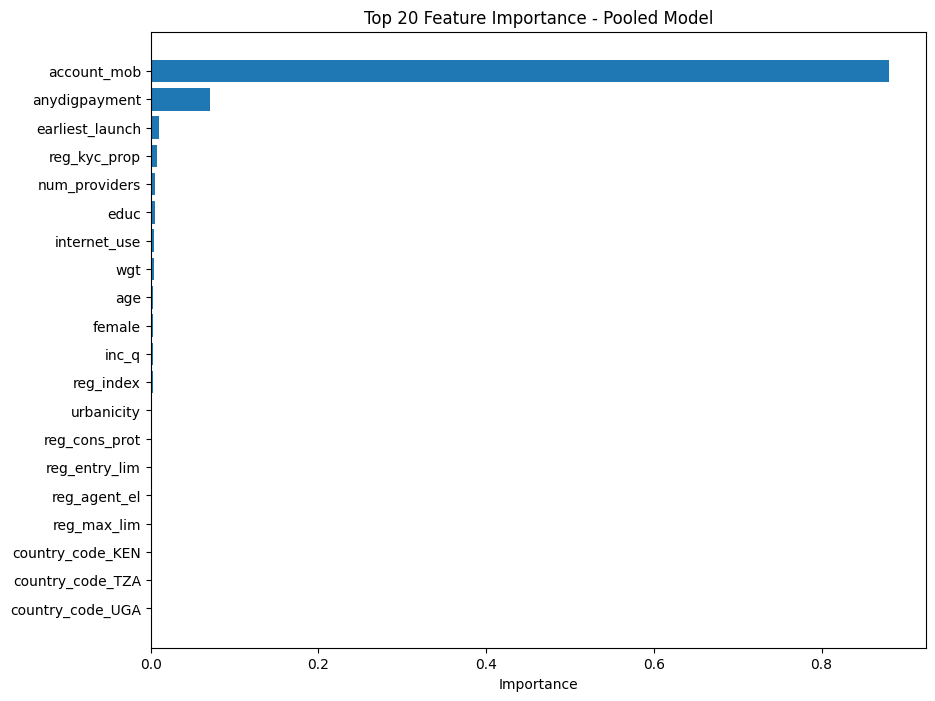

In [45]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":pooled_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

display(importance.head(20))

plt.figure(figsize=(10,8))

plt.barh(

    importance.head(20)["Feature"][::-1],

    importance.head(20)["Importance"][::-1]

)

plt.title("Top 20 Feature Importance - Pooled Model")

plt.xlabel("Importance")

plt.show()

In [46]:
MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

In [47]:
#  SAVE POOLED MODEL

joblib.dump(

    pooled_model,

    os.path.join(

        MODEL_PATH,

        "pooled_model.joblib"

    )

)

print("Pooled model saved successfully.")

print(os.listdir(MODEL_PATH))

Pooled model saved successfully.
['pooled_model.joblib', 'feature_columns.joblib']


**CREATE HARMONIZED TRAINING DATA**

In [48]:
# HARMONIZED TRAINING DATA

train_data = X_train.copy()
train_data["target"] = y_train
train_data["country"] = country_train.values

min_country_count = train_data["country"].value_counts().min()

harmonized_train = (
    train_data
    .groupby("country", group_keys=False)
    .apply(lambda x: x.sample(min_country_count, random_state=42))
)

X_train_harmonized = harmonized_train.drop(columns=["target", "country"])
y_train_harmonized = harmonized_train["target"]

print("Harmonized training distribution:")
print(harmonized_train["country"].value_counts())

Harmonized training distribution:
country
KEN    784
TZA    784
UGA    784
Name: count, dtype: int64


In [49]:
# TRAIN HARMONIZED MODEL
harmonized_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

harmonized_model.fit(X_train_harmonized, y_train_harmonized)

print("Harmonized model trained successfully.")

Harmonized model trained successfully.


In [50]:
# EVALUATE AND SAVE HARMONIZED MODEL

harm_pred = harmonized_model.predict(X_test)
harm_prob = harmonized_model.predict_proba(X_test)[:, 1]

print("Harmonized Model Performance")
print("Accuracy :", accuracy_score(y_test, harm_pred))
print("Precision:", precision_score(y_test, harm_pred))
print("Recall   :", recall_score(y_test, harm_pred))
print("F1 Score :", f1_score(y_test, harm_pred))
print("ROC AUC  :", roc_auc_score(y_test, harm_prob))

joblib.dump(
    harmonized_model,
    os.path.join(
        MODEL_PATH,
        "harmonized_model.joblib"
    )
)

print("\nSaved harmonized_model.joblib")

Harmonized Model Performance
Accuracy : 0.99
Precision: 0.9955947136563876
Recall   : 0.9912280701754386
F1 Score : 0.9934065934065934
ROC AUC  : 0.9955226608187135

Saved harmonized_model.joblib


**Expert Training Function**

In [51]:
#  DEFINE EXPERT TRAINING FUNCTION


def train_country_expert(country_name, X_train, y_train, country_train):

    print(f"\nTraining {country_name} expert...")

    mask = country_train.astype(str).str.upper().values == country_name

    X_country = X_train.loc[mask].copy()
    y_country = y_train.loc[mask].copy()

    print(f"{country_name} samples:", X_country.shape)

    expert_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )

    expert_model.fit(X_country, y_country)

    save_path = os.path.join(
        MODEL_PATH,
        f"expert_model_{country_name}.joblib"
    )

    joblib.dump(expert_model, save_path)

    print(f"Saved expert_model_{country_name}.joblib")

    return expert_model

In [52]:
# TRAIN COUNTRY EXPERT MODELS

countries = ["KEN", "TZA", "UGA"]

expert_models = {}

for c in countries:
    expert_models[c] = train_country_expert(
        c,
        X_train,
        y_train,
        country_train
    )

print("\nAll expert models trained and saved.")
print(expert_models.keys())


Training KEN expert...
KEN samples: (801, 21)
Saved expert_model_KEN.joblib

Training TZA expert...
TZA samples: (815, 21)
Saved expert_model_TZA.joblib

Training UGA expert...
UGA samples: (784, 21)
Saved expert_model_UGA.joblib

All expert models trained and saved.
dict_keys(['KEN', 'TZA', 'UGA'])


In [53]:
# EVALUATE COUNTRY EXPERT MODELS

expert_results = []

for_country = country_test.astype(str).str.upper()

for c in countries:

    mask = for_country.values == c

    X_country_test = X_test.loc[mask]
    y_country_test = y_test.loc[mask]

    pred = expert_models[c].predict(X_country_test)
    prob = expert_models[c].predict_proba(X_country_test)[:, 1]

    expert_results.append({
        "Model": f"Expert_{c}",
        "Accuracy": accuracy_score(y_country_test, pred),
        "Precision": precision_score(y_country_test, pred),
        "Recall": recall_score(y_country_test, pred),
        "F1": f1_score(y_country_test, pred),
        "ROC_AUC": roc_auc_score(y_country_test, prob)
    })

expert_results_df = pd.DataFrame(expert_results)

display(expert_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Expert_KEN,0.9899,0.9944,0.9944,0.9944,0.9987
1,Expert_TZA,0.9730,0.9730,0.9818,0.9774,0.9984
2,Expert_UGA,0.9861,0.9940,0.9881,0.9910,0.9915


In [54]:
# FULL MODEL COMPARISON TABLE
# Accuracy, F1, ROC-AUC for each model

def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }


comparison_results = []

# Pooled model
pooled_pred = pooled_model.predict(X_test)
pooled_prob = pooled_model.predict_proba(X_test)[:, 1]

comparison_results.append(
    evaluate_model(
        "Pooled",
        y_test,
        pooled_pred,
        pooled_prob
    )
)

# Harmonized model
harm_pred = harmonized_model.predict(X_test)
harm_prob = harmonized_model.predict_proba(X_test)[:, 1]

comparison_results.append(
    evaluate_model(
        "Harmonized",
        y_test,
        harm_pred,
        harm_prob
    )
)

# Expert models
# Each expert is evaluated only on its own country
country_test_clean = country_test.astype(str).str.upper()

for c in countries:

    mask = country_test_clean.values == c

    X_country_test = X_test.loc[mask]
    y_country_test = y_test.loc[mask]

    expert_pred = expert_models[c].predict(X_country_test)
    expert_prob = expert_models[c].predict_proba(X_country_test)[:, 1]

    comparison_results.append(
        evaluate_model(
            f"Expert_{c}",
            y_country_test,
            expert_pred,
            expert_prob
        )
    )

comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

joblib.dump(
    comparison_df,
    os.path.join(MODEL_PATH, "model_comparison_results.joblib")
)

print("Saved model_comparison_results.joblib")

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Harmonized,0.9900,0.9956,0.9912,0.9934,0.9955
1,Expert_KEN,0.9899,0.9944,0.9944,0.9944,0.9987
2,Pooled,0.9883,0.9934,0.9912,0.9923,0.9955
3,Expert_UGA,0.9861,0.9940,0.9881,0.9910,0.9915
4,Expert_TZA,0.9730,0.9730,0.9818,0.9774,0.9984


Saved model_comparison_results.joblib


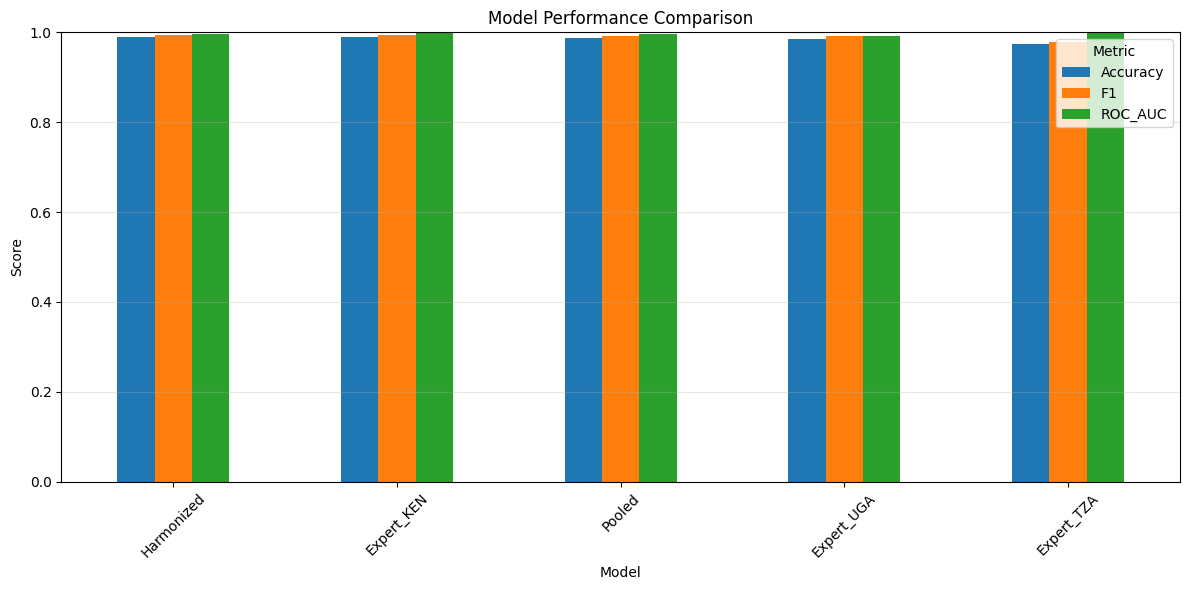

In [55]:
#  PLOT MODEL COMPARISON
# Accuracy, F1, and ROC-AUC

metrics_df = comparison_df[
    ["Model", "Accuracy", "F1", "ROC_AUC"]
].set_index("Model")

ax = metrics_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Feature Comparisson**

In [ ]:
# FEATURE IMPACT COMPARISON FOR EACH MODEL

def get_feature_importance_df(model, model_name, feature_names, top_n=10):

    fi = pd.DataFrame({
        "Model": model_name,
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    fi = fi.sort_values(
        by="Importance",
        ascending=False
    ).head(top_n)

    return fi


# Collect feature importance


all_fi_tables = []

all_fi_tables.append(
    get_feature_importance_df(
        pooled_model,
        "Pooled",
        X_train.columns,
        top_n=10
    )
)

all_fi_tables.append(
    get_feature_importance_df(
        harmonized_model,
        "Harmonized",
        X_train.columns,
        top_n=10
    )
)

for c in countries:
    all_fi_tables.append(
        get_feature_importance_df(
            expert_models[c],
            f"Expert_{c}",
            X_train.columns,
            top_n=10
        )
    )

feature_impact_df = pd.concat(
    all_fi_tables,
    ignore_index=True
)

display(feature_impact_df)


# Save feature impact table

joblib.dump(
    feature_impact_df,
    os.path.join(
        MODEL_PATH,
        "feature_impact_table.joblib"
    )
)

feature_impact_df.to_csv(
    os.path.join(
        MODEL_PATH,
        "feature_impact_table.csv"
    ),
    index=False
)


# Plot all models in one row

model_order = [
    "Pooled",
    "Harmonized",
    "Expert_KEN",
    "Expert_TZA",
    "Expert_UGA"
]

colors = {
    "Pooled": "#1f77b4",
    "Harmonized": "#ff7f0e",
    "Expert_KEN": "#2ca02c",
    "Expert_TZA": "#d62728",
    "Expert_UGA": "#9467bd"
}

fig, axes = plt.subplots(
    1,
    len(model_order),
    figsize=(26, 7),
    sharex=False
)

for ax, model_name in zip(axes, model_order):

    temp = feature_impact_df[
        feature_impact_df["Model"] == model_name
    ].sort_values(
        by="Importance",
        ascending=True
    )

    ax.barh(
        temp["Feature"],
        temp["Importance"],
        color=colors[model_name]
    )

    ax.set_title(model_name)
    ax.set_xlabel("Importance")

    ax.tick_params(axis="y", labelsize=8)

plt.suptitle(
    "Top Feature Impacts by Model",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

figure_path = os.path.join(
    MODEL_PATH,
    "feature_impact_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved feature impact chart:")
print(figure_path)

**Building Model Probability**

In [ ]:
# BUILD MODEL PROBABILITIES

def get_model_probabilities(X_data):

    probs = pd.DataFrame(index=X_data.index)

    probs["Pooled"] = pooled_model.predict_proba(X_data)[:, 1]
    probs["Harmonized"] = harmonized_model.predict_proba(X_data)[:, 1]

    for c in countries:
        probs[f"Expert_{c}"] = expert_models[c].predict_proba(X_data)[:, 1]

    return probs


train_model_probs = get_model_probabilities(X_train)
test_model_probs = get_model_probabilities(X_test)

display(train_model_probs.head())

In [ ]:
# BUILD ROUTING LABELS

def build_routing_labels(model_probs, y_true):

    routing_labels = []

    for idx in model_probs.index:

        true_value = y_true.loc[idx]

        row_probs = model_probs.loc[idx]

        errors = abs(row_probs - true_value)

        best_model = errors.idxmin()

        routing_labels.append(best_model)

    return pd.Series(routing_labels, index=model_probs.index)


routing_labels_train = build_routing_labels(
    train_model_probs,
    y_train
)

routing_labels_test = build_routing_labels(
    test_model_probs,
    y_test
)

print("Routing label distribution:")
print(routing_labels_train.value_counts())

In [ ]:
# TRAIN ROUTING MODEL

from sklearn.ensemble import RandomForestClassifier

router_X_train = pd.concat(
    [X_train, train_model_probs],
    axis=1
)

router_X_test = pd.concat(
    [X_test, test_model_probs],
    axis=1
)

routing_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

routing_model.fit(
    router_X_train,
    routing_labels_train
)

print("Routing model trained successfully.")
print("Router classes:", routing_model.classes_)

In [ ]:
#  EVALUATE ROUTER

router_pred = routing_model.predict(router_X_test)

router_accuracy = accuracy_score(
    routing_labels_test,
    router_pred
)

print("Router Accuracy:", router_accuracy)

print("\nRouting Classification Report:")
print(classification_report(routing_labels_test, router_pred))

In [ ]:
#  FINAL MOE PREDICTION
selected_models = pd.Series(
    router_pred,
    index=X_test.index
)

moe_probs = []

for idx in X_test.index:

    selected_model = selected_models.loc[idx]

    prob = test_model_probs.loc[idx, selected_model]

    moe_probs.append(prob)

moe_probs = np.array(moe_probs)

moe_pred = (moe_probs >= 0.5).astype(int)

moe_metrics = {
    "Model": "MoE_Router",
    "Accuracy": accuracy_score(y_test, moe_pred),
    "Precision": precision_score(y_test, moe_pred, zero_division=0),
    "Recall": recall_score(y_test, moe_pred, zero_division=0),
    "F1": f1_score(y_test, moe_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, moe_probs)
}

moe_metrics

In [ ]:
# FINAL MODEL COMPARISON

final_comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame([moe_metrics])
    ],
    ignore_index=True
)

final_comparison_df = final_comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(final_comparison_df)

joblib.dump(
    final_comparison_df,
    os.path.join(MODEL_PATH, "final_model_comparison.joblib")
)

final_comparison_df.to_csv(
    os.path.join(MODEL_PATH, "final_model_comparison.csv"),
    index=False
)

In [ ]:
# FINAL COMPARISON CHART

metrics_df = final_comparison_df[
    ["Model", "Accuracy", "F1", "ROC_AUC"]
].set_index("Model")

ax = metrics_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()

chart_path = os.path.join(
    MODEL_PATH,
    "final_model_comparison_chart.png"
)

plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)

In [ ]:
#  SHAP EXPLAINABILITY

!pip install shap -q

import shap

shap_sample = X_test.sample(
    min(200, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(pooled_model)

shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Impact - Pooled Model")
plt.tight_layout()

shap_path = os.path.join(
    MODEL_PATH,
    "shap_feature_impact_pooled.png"
)

plt.savefig(shap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SHAP chart:", shap_path)

In [ ]:
# SAVE ROUTER AND SUPPORT FILES

joblib.dump(
    routing_model,
    os.path.join(MODEL_PATH, "routing_model.joblib")
)

joblib.dump(
    train_model_probs.columns.tolist(),
    os.path.join(MODEL_PATH, "model_probability_columns.joblib")
)

print("Saved routing_model.joblib")
print("Saved model_probability_columns.joblib")

print("\nFiles in model folder:")
for f in sorted(os.listdir(MODEL_PATH)):
    print(f)

In [ ]:
import os

for f in sorted(os.listdir("/content/drive/MyDrive/Financial_Inclusion_Models")):
    print(f)

In [ ]:
#Verify all files
import os

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

for f in sorted(os.listdir(MODEL_PATH)):
    print(f)

In [ ]:
#View Mode Details

import joblib

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

files = [
    "pooled_model.joblib",
    "harmonized_model.joblib",
    "expert_model_KEN.joblib",
    "expert_model_TZA.joblib",
    "expert_model_UGA.joblib",
    "routing_model.joblib"
]

for file in files:

    model = joblib.load(f"{MODEL_PATH}/{file}")

    print("\n" + "="*60)
    print(file)
    print(type(model))

    if hasattr(model, "feature_importances_"):
        print("Features:", len(model.feature_importances_))

    if hasattr(model, "classes_"):
        print("Classes:", model.classes_)

In [ ]:
#Viewing Final Model Comparison
import pandas as pd

comparison = pd.read_csv(
    "/content/drive/MyDrive/Financial_Inclusion_Models/final_model_comparison.csv"
)

display(comparison)

In [ ]:
import joblib

joblib.dump(
    X.columns.tolist(),
    "/content/drive/MyDrive/Financial_Inclusion_Models/feature_columns.joblib"
)

print("feature_columns.joblib saved.")

In [ ]:
import joblib

features = joblib.load(
    "/content/drive/MyDrive/Financial_Inclusion_Models/feature_columns.joblib"
)

print("Number of features:", len(features))
print(features[:10])

In [ ]:

import os

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

required_files = [

    "feature_columns.joblib",

    "pooled_model.joblib",
    "harmonized_model.joblib",

    "expert_model_KEN.joblib",
    "expert_model_TZA.joblib",
    "expert_model_UGA.joblib",

    "routing_model.joblib",

    "final_model_comparison.csv",
    "feature_impact_table.csv",

    "final_model_comparison_chart.png",
    "feature_impact_comparison.png",
    "shap_feature_impact_pooled.png",

    "cleanfinancialinclusion.ipynb"
]

print("CHECKING FILES\n")

for file in required_files:

    exists = os.path.exists(
        os.path.join(MODEL_PATH, file)
    )

    print(f"{file:<40} {'✅' if exists else '❌'}")


**Splitting Global the dataset**

In [ ]:
# FINAL CONSISTENT TRAIN-TEST SPLIT (Use This)

from sklearn.model_selection import train_test_split

print("Creating ONE consistent train-test split for ALL models...\n")

# Use your final cleaned dataset
df = df_final.copy()

X = df.drop(columns=['account_mob'])
y = df['account_mob'].copy()

country_series = df['country_code'].copy()

# This is the main split — use it for everything
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Keep country labels aligned
country_train = country_series.loc[X_train.index].reset_index(drop=True)
country_test  = country_series.loc[X_test.index].reset_index(drop=True)

print("✅ Consistent split created!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Country distribution in test:\n{country_test.value_counts()}")

# Global Train-Test Split + Defining X_train / X_test

from sklearn.model_selection import train_test_split

print("Performing global train-test split...\n")

# Define target and features
y = df_final['account_mob'].copy()                    # Target variable
X = df_final.drop(columns=['account_mob'])            # Drop only the target

# Keep country_code for later subsetting (very important!)
country_series = df_final['country_code'].copy()

# Train-test split (stratified by target)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Preserve country labels aligned with train/test sets
country_train = country_series.loc[X_train.index]
country_test  = country_series.loc[X_test.index]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"Country distribution in train:\n{country_train.value_counts()}")

In [ ]:
# One-Hot Encoding (Leakage-safe)
# Identify categorical columns (exclude country_code and target)
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove 'country_code' from encoding (we already have it in country_train/test)
if 'country_code' in categorical_cols:
    categorical_cols.remove('country_code')

print(f"Encoding categorical columns: {categorical_cols}")

# One-hot encode
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# Align columns (important!)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Final assignment
X_train = X_train_encoded
X_test  = X_test_encoded

print(f"Final X_train shape after encoding: {X_train.shape}")
print(f"Final X_test shape after encoding : {X_test.shape}")
print("All columns are now numeric:", X_train.dtypes.unique())

**Training Pooled Model**

In [ ]:
# LOAD CLEAN DATASET & POOLED MODELS
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import joblib
import os

print("Loading clean dataset...")

# Load the recommended dataset
df = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv')

print(f"Dataset loaded: {df.shape}")
print("Country distribution:\n", df['country_code'].value_counts())

In [ ]:
# TRAINING SECTION
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import joblib

print("🔄 Preparing clean training data...")

# Use consistent target
TARGET = 'dig_account'   # or 'account_mob' — choose one and stick with it

# Drop leakage columns and target
drop_cols = ['country_code', 'mmpi_2023','account_mob', 'anydigpayment', TARGET,]

X = df_final.drop(columns=drop_cols)
y = df_final[TARGET]

print(f"Features used: {list(X.columns)}")
print(f"Target: {TARGET} | Positive rate: {y.mean():.1%}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Train Pooled Model
pooled_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

pooled_model.fit(X_train, y_train)

# Save properly
joblib.dump(pooled_model, 'model_pooled.joblib')
joblib.dump(list(X_train.columns), 'feature_names.joblib')

print("✅ Pooled model trained and saved successfully")

**Training the Expert model**

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

from google.colab import drive

In [ ]:
#Load Data
print("Loading clean dataset...")

df = pd.read_csv(
    "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv"
)
df = df.reset_index(drop=True)
print(f"Dataset loaded: {df.shape}")
print(df["country_code"].value_counts())

In [ ]:
# LOAD DATA
df = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv')
df = df.reset_index(drop=True)

# DEFINE TARGET
y = df["dig_account"].astype(int)

In [ ]:
print("Loading clean dataset...")

df = pd.read_csv(
    "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv"
)

print(df.shape)
print(df.columns)

print("\nTarget check:")
print("dig_account:", "dig_account" in df.columns)
print("Any_digital:", "Any_digital" in df.columns)

**Global DATASET**

In [ ]:
#Global Clean Dataset
def clean_features(df):

    df = df.copy()

    # remove obvious leakage columns if still present
    for col in ["dig_account", "Any_digital"]:
        if col in df.columns:
            df = df.drop(columns=[col])

    # convert ALL object columns safely
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str)

    # one-hot encode everything categorical
    df = pd.get_dummies(df, drop_first=True)

    return df

**Clean Master Dataset**

In [ ]:
#Master Dataset
df = df.reset_index(drop=True)

target = "dig_account"  # confirm correct

y = df[target].astype(int)
country = df["country_code"].astype(str)

X_raw = df.drop(columns=[target])

X = clean_features(X_raw)

In [ ]:
#BASIC PREPROCESSING
target_col = "dig_account"   # OR "Any_digital"

# Separate features and target
leak_cols = [target_col]

# Only drop if they exist
for col in ["account_mob", "anydigpayment"]:
    if col in X.columns:
        X = X.drop(columns=[col])
target_col = "dig_account"

y = df[target_col].astype(int)
country = df["country_code"].astype(str)

X = df.drop(columns=[target_col])
X = pd.get_dummies(X, drop_first=True)

# Convert categorical features (safe quick encoding)
X = pd.get_dummies(X, drop_first=True)

print("Final feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

In [ ]:
#CLEAN FEATURES FIRST (GLOBAL)
X_raw = df.drop(columns=["dig_account"])  # target removed
country_series = df["country_code"].astype(str)

X_moe = clean_features(X_raw)

In [ ]:
#Verify Data
print(X_moe.dtypes.value_counts())
print(X_moe.head())

In [ ]:
#DEFINE EXPERT TRAINING FUNCTION
countries = ["KEN", "TZA", "UGA"]

experts = {}

for c in countries:
    experts[c] = train_expert(c, X_moe, y, country_series)

print(experts.keys())

In [ ]:
#FIX EXPERT FUNCTION
def train_expert(country_name, X, y, country_series):

    print(f"\nTraining expert for {country_name}...")

    mask = (country_series == country_name)

    X_c = X.loc[mask].copy()
    y_c = y.loc[mask].copy()

    from sklearn.model_selection import train_test_split

    X_train, X_val, y_train, y_val = train_test_split(
        X_c, y_c,
        test_size=0.2,
        random_state=42,
        stratify=y_c
    )

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    joblib.dump(model, f"/content/drive/MyDrive/expert_model_{country_name}.joblib")

    print(f"Saved: expert_model_{country_name}.joblib")

    return model

In [ ]:
df = df.reset_index(drop=True)

target = "dig_account"

y = df[target].astype(int)
country_series = df["country_code"].astype(str).str.strip().str.upper()

X_raw = df.drop(columns=[target])

X_moe = clean_features(X_raw)

In [ ]:
#TRAIN ALL EXPERTS (FIXED LOOP)
countries = ["KEN", "TZA", "UGA"]

experts = {}

for c in countries:
    experts[c] = train_expert(c, X_moe, y, country_series)

print("\nAll experts trained successfully.")

In [ ]:
#Training Expert Loop
countries = ["KEN", "TZA", "UGA"]

experts = {}

for c in countries:

   train_expert(c, X, y, df["country_code"])

print("\nAll experts trained successfully.")

In [ ]:
#Confirm files are saved in google drive
import os

drive_path = "/content/drive/MyDrive/"

print("Saved expert models:")
for c in countries:
    print(os.path.exists(drive_path + f"expert_model_{c}.joblib"),
          f"expert_model_{c}.joblib")

In [ ]:
print("Global X_train features count:", len(X_train.columns))
print("First 10 features in X_train:", X_train.columns.tolist()[:10])

**Pooled Model**

In [ ]:
#CLEAN DATA SPLIT
df = df.reset_index(drop=True)

target = "dig_account"  # confirm this exists

y = df[target].astype(int)
country = df["country_code"].astype(str)

X = df.drop(columns=[target])

In [ ]:
print(X.dtypes)

In [ ]:
#POOLED MODEL
X_pooled = clean_features(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pooled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pooled_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

pooled_model.fit(X_train_p, y_train_p)

pooled_acc = pooled_model.score(X_test_p, y_test_p)

print("Pooled Accuracy:", pooled_acc)

In [ ]:
#Harmony Model
X_harm = X.copy()

# ensure country stays as feature
X_harm = clean_features(X_harm)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_harm, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

harm_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

harm_model.fit(X_train_h, y_train_h)

harm_acc = harm_model.score(X_test_h, y_test_h)

print("Harmonized Accuracy:", harm_acc)

**Routing Model Training**

In [ ]:
#Router Training
router_y = country_series

In [ ]:
#Router Feature
router_X = X_moe.copy()

In [ ]:
#Train Router Model
from sklearn.ensemble import RandomForestClassifier

router_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    router_X, router_y,
    test_size=0.2,
    random_state=42,
    stratify=router_y
)

router_model.fit(X_train_r, y_train_r)

router_acc = router_model.score(X_test_r, y_test_r)

print("Router Accuracy:", router_acc)

**MoE Prediction**

In [ ]:
#MoE Prediction
def moe_predict(X_input):

    country_pred = router_model.predict(X_input)[0]

    expert = experts[country_pred]

    return expert.predict_proba(X_input)[0, 1]

In [ ]:
print(country_series.unique())
print(experts.keys())

In [ ]:
#MoE Full Accuracy Test
preds = []

for i in range(len(X_moe)):

    row = X_moe.iloc[[i]]

    country_pred = router_model.predict(row)[0]
    prob = experts[country_pred].predict_proba(row)[0, 1]

    preds.append(prob)

moe_acc = ((np.array(preds) >= 0.5) == y.values).mean()

print("MoE Accuracy:", moe_acc)

**EXPERT MODEL EVALUATION**

In [ ]:
#MODELS EVALUATION
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib

print("Loading clean dataset for evaluation...")
df = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv')

# Load trained experts
experts = joblib.load('trained_models/experts.joblib')
print("✅ Loaded experts for:", list(experts.keys()))

In [ ]:
#  PREPARE TEST SET
TARGET = 'dig_account'

# Use the same drop columns as during training
drop_cols = ['country_code', 'mmpi_2023', TARGET, 'account_mob']

X = df.drop(columns=drop_cols)
y = df[TARGET]

# Re-create train/test split with same random_state for consistency
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Rebuild country_test from the clean df
country_test = df.loc[X_test.index, 'country_code'].astype(str).str.strip()

print("Test set country distribution:")
print(country_test.value_counts())

In [ ]:
# EVALUATE EXPERTS
results = []

for country, model in experts.items():
    print(f"\n→ Evaluating Expert for {country}")

    mask = (country_test == country)
    samples = mask.sum()

    if samples == 0:
        print(f"  ❌ No samples for {country}")
        continue

    X_test_c = X_test.loc[mask].copy()
    y_test_c = y_test.loc[mask].copy()

    # Align features to this expert model's training features
    if hasattr(model, 'feature_names_in_'):
        trained_features = model.feature_names_in_
    else:
        trained_features = X_train.columns.tolist()

    X_test_c = X_test_c.reindex(columns=trained_features, fill_value=0)

    # Predict
    preds = model.predict(X_test_c)
    probs = model.predict_proba(X_test_c)[:, 1]

    results.append({
        "Model": f"Expert_{country}",
        "Country": country,
        "Samples": int(samples),
        "Accuracy": accuracy_score(y_test_c, preds),
        "F1": f1_score(y_test_c, preds, zero_division=0),
        "AUC": roc_auc_score(y_test_c, probs)
    })

    print(f"  ✅ Samples: {samples} | "
          f"Accuracy: {accuracy_score(y_test_c, preds):.4f} | "
          f"F1: {f1_score(y_test_c, preds, zero_division=0):.4f} | "
          f"AUC: {roc_auc_score(y_test_c, probs):.4f}")


In [ ]:
#  SHOW RESULTS
if results:
    results_df = pd.DataFrame(results).round(4)
    print("\n" + "="*80)
    print("EXPERT MODELS EVALUATION RESULTS")
    print("="*80)
    print(results_df.to_string(index=False))
else:
    print("\n❌ No results generated.")

**Evaluate all Models Fairly**

In [ ]:
# Evaluate All Models Fairly
# Pooled model vs Country-specific Expert model

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

print("Evaluating All Models Fairly...\n")

results = []


**FULL COMPARISON: POOLED VS EXPERT MODELS**

In [ ]:
# FULL COMPARISON: POOLED vs EXPERT MODELS
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("="*90)
print("FINAL COMPARISON: POOLED vs EXPERT MODELS")
print("="*90)

# Load clean dataset
df = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv')

TARGET = 'dig_account'
drop_cols = ['country_code', 'mmpi_2023', TARGET, 'account_mob']

X = df.drop(columns=drop_cols)
y = df[TARGET]

# Re-create consistent train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

country_test = df.loc[X_test.index, 'country_code'].astype(str).str.strip()

In [ ]:
#  POOLED MODEL
print("Evaluating Pooled Model...")

X_test_aligned = X_test.reindex(columns=pooled_model.feature_names_in_
                                if hasattr(pooled_model, 'feature_names_in_')
                                else X_train.columns, fill_value=0)

pooled_preds = pooled_model.predict(X_test_aligned)
pooled_probs = pooled_model.predict_proba(X_test_aligned)[:, 1]

results.append({
    'Model': 'Pooled', 'Country': 'All',
    'Samples': len(y_test),
    'Accuracy': accuracy_score(y_test, pooled_preds),
    'F1': f1_score(y_test, pooled_preds, zero_division=0),
    'AUC': roc_auc_score(y_test, pooled_probs)
})

# Pooled per country
for country in ['KEN', 'TZA', 'UGA']:
    mask = (country_test == country)
    if mask.sum() == 0: continue
    results.append({
        'Model': 'Pooled', 'Country': country,
        'Samples': int(mask.sum()),
        'Accuracy': accuracy_score(y_test[mask], pooled_preds[mask]),
        'F1': f1_score(y_test[mask], pooled_preds[mask], zero_division=0),
        'AUC': roc_auc_score(y_test[mask], pooled_probs[mask])
    })


In [ ]:
#  EXPERT MODELS
print("\nEvaluating Expert Models...")
for country, model in experts.items():
    mask = (country_test == country)
    if mask.sum() == 0: continue

    X_test_c = X_test.loc[mask].copy()

    if hasattr(model, 'feature_names_in_'):
        X_test_c = X_test_c.reindex(columns=model.feature_names_in_, fill_value=0)

    preds = model.predict(X_test_c)
    probs = model.predict_proba(X_test_c)[:, 1]

    results.append({
        'Model': f'Expert_{country}',
        'Country': country,
        'Samples': int(mask.sum()),
        'Accuracy': accuracy_score(y_test[mask], preds),
        'F1': f1_score(y_test[mask], preds, zero_division=0),
        'AUC': roc_auc_score(y_test[mask], probs)
    })

In [ ]:
# HARMONIZED POOLED MODEL (with Country Interactions)

from xgboost import XGBClassifier
import joblib

print("Training Harmonized Pooled Model with Country Interactions...\n")

# Create copies to avoid modifying original data
X_harm = X_train.copy()
X_test_harm = X_test.copy()

# Add country_code as a feature
X_harm['country_code'] = country_train.values
X_test_harm['country_code'] = country_test.values

# Create important interaction terms
interaction_cols = ['female', 'urbanicity', 'inc_q', 'educ', 'reg_index', 'num_providers']

for col in interaction_cols:
    if col in X_harm.columns:
        X_harm[f'{col}_x_country'] = X_harm[col].astype(str) + '_' + X_harm['country_code']
        X_test_harm[f'{col}_x_country'] = X_test_harm[col].astype(str) + '_' + X_test_harm['country_code']

# One-hot encode country and interaction terms
cat_cols = ['country_code'] + [c for c in X_harm.columns if '_x_country' in str(c)]
X_harm = pd.get_dummies(X_harm, columns=cat_cols, drop_first=True)
X_test_harm = pd.get_dummies(X_test_harm, columns=cat_cols, drop_first=True)

# Align test set columns with training
X_test_harm = X_test_harm.reindex(columns=X_harm.columns, fill_value=0)

print(f"Harmonized feature count: {X_harm.shape[1]}")

# Train Harmonized Model
model_harmonized = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

model_harmonized.fit(X_harm, y_train)

# Save model
joblib.dump(model_harmonized, 'model_harmonized.pkl')

print("✅ Harmonized Pooled Model trained and saved successfully!")
print(f"Training samples: {X_harm.shape[0]} | Features: {X_harm.shape[1]}")

In [ ]:
# FINAL COMPARISON: POOLED vs HARMONIZED vs EXPERT MODELS

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

print("="*90)
print("FINAL MODEL COMPARISON: POOLED vs HARMONIZED vs EXPERTS")
print("="*90)

results = []

# Simple Pooled Model
if 'model_pooled' in globals():
    preds = model_pooled.predict(X_test)
    probs = model_pooled.predict_proba(X_test)[:, 1]

    results.append({
        'Model': 'Pooled',
        'Country': 'All',
        'Samples': len(y_test),
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds, zero_division=0),
        'AUC': roc_auc_score(y_test, probs)
    })
    print("✅ Pooled Model evaluated")

In [ ]:
# STANDARD POOLED MODEL (Main Baseline)
if 'model_pooled' in globals():
    preds = model_pooled.predict(X_test)
    probs = model_pooled.predict_proba(X_test)[:, 1]

    results.append({
        'Model': 'Standard Pooled',
        'Country': 'All',
        'Samples': len(y_test),
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds, zero_division=0),
        'AUC': roc_auc_score(y_test, probs)
    })
    print("✅ Standard Pooled evaluated")

In [ ]:
# Harmonized Pooled Model
if 'model_harmonized' in globals():
    X_test_harm = X_test.copy()
    X_test_harm['country_code'] = country_test.values

    for col in ['female', 'urbanicity', 'inc_q', 'educ', 'reg_index']:
        if col in X_test_harm.columns:
            X_test_harm[f'{col}_x_country'] = X_test_harm[col].astype(str) + '_' + X_test_harm['country_code']

    cat_cols = ['country_code'] + [c for c in X_test_harm.columns if '_x_country' in c]
    X_test_harm = pd.get_dummies(X_test_harm, columns=cat_cols, drop_first=True)

    if hasattr(model_harmonized, 'feature_names_in_'):
        X_test_harm = X_test_harm.reindex(columns=model_harmonized.feature_names_in_, fill_value=0)

    preds = model_harmonized.predict(X_test_harm)
    probs = model_harmonized.predict_proba(X_test_harm)[:, 1]

    results.append({
        'Model': 'Harmonized Pooled',
        'Country': 'All',
        'Samples': len(y_test),
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds, zero_division=0),
        'AUC': roc_auc_score(y_test, probs)
    })
    print("✅ Harmonized Pooled Model evaluated")

In [ ]:
# Country Expert Models
if 'experts' in globals() and experts:
    for country, model in experts.items():
        mask = (country_test == country)
        if mask.sum() == 0:
            continue

        X_test_c = X_test.loc[mask].copy()

        if hasattr(model, 'feature_names_in_'):
            X_test_c = X_test_c.reindex(columns=model.feature_names_in_, fill_value=0)

        preds = model.predict(X_test_c)
        probs = model.predict_proba(X_test_c)[:, 1]

        results.append({
            'Model': f'Expert_{country}',
            'Country': country,
            'Samples': int(mask.sum()),
            'Accuracy': accuracy_score(y_test[mask], preds),
            'F1': f1_score(y_test[mask], preds, zero_division=0),
            'AUC': roc_auc_score(y_test[mask], probs)
        })
        print(f"✅ Expert_{country} evaluated")

In [ ]:
# Final Table
results_df = pd.DataFrame(results).round(4)

print("\n" + "="*100)
print("FINAL RESULTS")
print("="*100)
print(results_df.to_string(index=False))

In [ ]:
# Final Results Table
display(
    results_df.style
    .format(precision=4)
    .highlight_max(color='lightgreen', subset=['Accuracy', 'F1', 'AUC'])
    .set_caption("Final Comparison: Standard Pooled vs Harmonized Pooled vs Expert Models")
)

# Save
results_df.to_csv('final_model_comparison.csv', index=False)
print("\n✅ Results saved to 'final_model_comparison.csv'")

In [ ]:
# PLOTTING CODE
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Remove duplicates and keep only necessary rows
plot_df = results_df.drop_duplicates().copy()

# Filter out the 'All' row for per-country comparison
plot_df_per_country = plot_df[plot_df['Country'] != 'All'].copy()

# Ensure proper data types
plot_df_per_country['Accuracy'] = pd.to_numeric(plot_df_per_country['Accuracy'])
plot_df_per_country['F1'] = pd.to_numeric(plot_df_per_country['F1'])
plot_df_per_country['AUC'] = pd.to_numeric(plot_df_per_country['AUC'])

print("Data being plotted:")
print(plot_df_per_country)

In [ ]:
import joblib
# Save harmonized model with .joblib extension
if 'model_harmonized' in globals():
    joblib.dump(model_harmonized, 'model_harmonized.joblib')
    print("✅ Saved as 'model_harmonized.joblib'")
else:
    print("❌ model_harmonized not found in globals")

In [ ]:
# Save harmonized feature names
if 'model_harmonized' in globals() and hasattr(model_harmonized, 'feature_names_in_'):
    harm_features = model_harmonized.feature_names_in_.tolist()
    joblib.dump(harm_features, 'harmonized_pooled_featurenames.joblib')
    print(f"✅ Saved harmonized_pooled_featurenames ({len(harm_features)} features)")

In [ ]:
# FINAL COMPARISON USING SAVED MODELS

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import joblib

print("="*100)
print("FINAL MODEL COMPARISON (Using Saved Models)")
print("="*100)

results = []

In [ ]:
# Load feature names from saved file
try:
    saved_feature_names = joblib.load('/content/Financial_Inclusion/feature_names.joblib')
    print(f"Loaded saved feature names: {len(saved_feature_names)} features")
except:
    saved_feature_names = X_train.columns.tolist()
    print("Using current X_train columns as fallback")

In [ ]:
# STANDARD POOLED MODEL
if 'model_pooled' in globals():
    # Align X_test to saved pooled model features
    X_test_aligned = X_test.reindex(columns=saved_feature_names, fill_value=0)

    preds = model_pooled.predict(X_test_aligned)
    probs = model_pooled.predict_proba(X_test_aligned)[:, 1]

    results.append({
        'Model': 'Standard Pooled',
        'Country': 'All',
        'Samples': len(y_test),
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds, zero_division=0),
        'AUC': roc_auc_score(y_test, probs)
    })
    print("✅ Standard Pooled evaluated")

In [ ]:
# EXPERT MODELS
if 'experts' in globals():
    for country, model in experts.items():
        mask = (country_test == country)
        if mask.sum() == 0:
            continue

        X_test_c = X_test.loc[mask].copy()

            # Align to this expert's features
        if hasattr(model, 'feature_names_in_'):
            expert_features = model.feature_names_in_
        else:
            expert_features = saved_feature_names

        X_test_c = X_test_c.reindex(columns=expert_features, fill_value=0)

        preds = model.predict(X_test_c)
        probs = model.predict_proba(X_test_c)[:, 1]

        results.append({
            'Model': f'Expert_{country}',
            'Country': country,
            'Samples': int(mask.sum()),
            'Accuracy': accuracy_score(y_test[mask], preds),
            'F1': f1_score(y_test[mask], preds, zero_division=0),
            'AUC': roc_auc_score(y_test[mask], probs)
        })
        print(f"✅ Expert_{country} evaluated")

In [ ]:
# HARMONIZED POOLED
if 'model_harmonized' in globals():
    X_test_h = X_test.copy()
    X_test_h['country_code'] = country_test.values

    for col in ['female', 'urbanicity', 'inc_q', 'educ', 'reg_index']:
        if col in X_test_h.columns:
            X_test_h[f'{col}_x_country'] = X_test_h[col].astype(str) + '_' + X_test_h['country_code']

    cat_cols = ['country_code'] + [c for c in X_test_h.columns if '_x_country' in c]
    X_test_h = pd.get_dummies(X_test_h, columns=cat_cols, drop_first=True)

    if hasattr(model_harmonized, 'feature_names_in_'):
        X_test_h = X_test_h.reindex(columns=model_harmonized.feature_names_in_, fill_value=0)

    preds = model_harmonized.predict(X_test_h)
    probs = model_harmonized.predict_proba(X_test_h)[:, 1]

    results.append({
        'Model': 'Harmonized Pooled',
        'Country': 'All',
        'Samples': len(y_test),
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds, zero_division=0),
        'AUC': roc_auc_score(y_test, probs)
    })

In [ ]:
# Display
results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

display(
    results_df.style
    .format(precision=4)
    .highlight_max(color='lightgreen', subset=['Accuracy', 'F1', 'AUC'])
    .set_caption("Final Comparison: Standard Pooled vs Harmonized Pooled vs Expert Models")
)

results_df.to_csv('final_model_comparison.csv', index=False)
print("\n✅ Saved to 'final_model_comparison.csv'")

In [ ]:
# PER MODEL COMPARISON GRAPH
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Prepare data
plot_df = results_df.copy()

# Melt for plotting
plot_melt = plot_df.melt(
    id_vars=['Model', 'Country'],
    value_vars=['Accuracy', 'F1', 'AUC'],
    var_name='Metric',
    value_name='Score'
)

# Create Per-Model Comparison Plot
plt.figure(figsize=(14, 8))

sns.barplot(
    data=plot_melt,
    x='Model',
    y='Score',
    hue='Metric',
    palette='Set2',
    dodge=True
)

plt.title('Per Model Comparison: Accuracy, F1 & AUC', fontsize=16, pad=20)
plt.ylabel('Score', fontsize=13)
plt.xlabel('Model', fontsize=13)
plt.xticks(rotation=15)
plt.ylim(0.75, 1.0)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add value labels on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Optional: Overall Performance Summary (Single Bar per Model)
overall_df = plot_df[plot_df['Country'] == 'All'].copy()

if not overall_df.empty:
    plt.figure(figsize=(12, 6))
    melt_overall = overall_df.melt(id_vars='Model', value_vars=['Accuracy', 'F1', 'AUC'])

    sns.barplot(
        data=melt_overall,
        x='Model',
        y='value',
        hue='variable',
        palette='Set2'
    )

    plt.title('Overall Performance Comparison Across All Countries', fontsize=15, pad=20)
    plt.ylabel('Score')
    plt.ylim(0.75, 1.0)
    plt.xticks(rotation=15)
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.show()

In [ ]:
# OVERALL POOLED PERFORMANCE
overall = plot_df[plot_df['Country'] == 'All']
if not overall.empty:
    metric_names = ['Accuracy', 'F1', 'AUC']
    values = overall.iloc[0][metric_names].values

    plt.figure(figsize=(8, 5))
    bars = sns.barplot(x=metric_names, y=values, palette='viridis')

    plt.title('Overall Pooled Model Performance', fontsize=14, pad=20)
    plt.ylabel('Score')
    plt.ylim(0.7, 0.9)

    for i, v in enumerate(values):
        bars.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

    plt.show()
    print("No 'All' row found in results_df for overall plot.")

In [ ]:
# HARMONIZED POOLED MODEL WITH COUNTRY INTERACTIONS

from xgboost import XGBClassifier
import pandas as pd

print("Training Harmonized Pooled Model with Country Interactions...\n")

# Make a copy to avoid modifying original
X_harm = X_train.copy()
X_test_harm = X_test.copy()

# 1. Add country as a categorical feature (important!)
X_harm['country_code'] = country_train.values
X_test_harm['country_code'] = country_test.values

#Create selected interaction terms (most important ones)
for col in ['female', 'urbanicity', 'inc_q', 'educ', 'reg_index', 'num_providers']:
    if col in X_harm.columns:
        X_harm[f'{col}_x_country'] = X_harm[col].astype(str) + '_' + X_harm['country_code']
        X_test_harm[f'{col}_x_country'] = X_test_harm[col].astype(str) + '_' + X_test_harm['country_code']

#One-hot encode country and interactions
cat_cols = ['country_code'] + [col for col in X_harm.columns if '_x_country' in col]

X_harm = pd.get_dummies(X_harm, columns=cat_cols, drop_first=True)
X_test_harm = pd.get_dummies(X_test_harm, columns=cat_cols, drop_first=True)

# Align columns
X_test_harm = X_test_harm.reindex(columns=X_harm.columns, fill_value=0)

print(f"Harmonized features: {X_harm.shape[1]}")

# Train Harmonized Pooled Model
model_harmonized = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

model_harmonized.fit(X_harm, y_train)

# Save
joblib.dump(model_harmonized, 'model_harmonized.pkl')

print("✅ Harmonized Pooled Model trained and saved successfully!")

In [ ]:
# Create folder
os.makedirs('/content/drive/MyDrive/Financial_Inclusion_Models', exist_ok=True)

# Save Harmonized Model
joblib.dump(
    model_harmonized,
    '/content/drive/MyDrive/Financial_Inclusion_Models/model_harmonized.joblib'
)

# Save Harmonized Features
joblib.dump(
    X_harm.columns.tolist(),
    '/content/drive/MyDrive/Financial_Inclusion_Models/harmonized_features.joblib'
)

print("✅ Harmonized model saved as .joblib")

**FEATURE IMPORTANCE COMPARISSON**

In [ ]:
# COLLECT FEATURE IMPORTANCES
importance_dict = {}

print("📊 Extracting Feature Importances...\n")

# POOLED MODEL
if 'pooled_model' in globals() and hasattr(pooled_model, 'feature_importances_'):
    if hasattr(pooled_model, 'feature_names_in_'):
        feat_names = pooled_model.feature_names_in_
    else:
        feat_names = X_train.columns.tolist() if 'X_train' in globals() else list(range(len(pooled_model.feature_importances_)))

    importance_dict['Pooled'] = pd.Series(
        pooled_model.feature_importances_,
        index=feat_names
    ).sort_values(ascending=False)
    print(f"✅ Pooled model: {len(feat_names)} features")
else:
    print("❌ pooled_model not found or has no feature_importances_")

# EXPERT MODELS
if 'experts' in globals():
    for country, model in experts.items():
        if hasattr(model, 'feature_importances_'):
            if hasattr(model, 'feature_names_in_'):
                feat_names = model.feature_names_in_
            else:
                feat_names = X_train.columns.tolist() if 'X_train' in globals() else list(range(len(model.feature_importances_)))

            importance_dict[f'Expert_{country}'] = pd.Series(
                model.feature_importances_,
                index=feat_names
            ).sort_values(ascending=False)
            print(f"✅ Expert_{country}: {len(feat_names)} features")
        else:
            print(f"⚠️ Expert_{country} has no feature_importances_")
else:
    print("❌ 'experts' dictionary not found")

print(f"\n✅ Total models with importance: {len(importance_dict)}")
print("Models found:", list(importance_dict.keys()))

In [ ]:
# FEATURE IMPORTANCE COMPARISON PLOTS
import matplotlib.pyplot as plt
import seaborn as sns

if not importance_dict:
    print("❌ No data in importance_dict")
else:
    n_models = len(importance_dict)
    top_n = 10  # Change to 12 or 15 if you want more features

    # Create subplots
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 9), sharey=False)
    if n_models == 1:
        axes = [axes]

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (model_name, imp_series) in enumerate(importance_dict.items()):
        top_features = imp_series.head(top_n)

        sns.barplot(
            ax=axes[i],
            x=top_features.values,
            y=top_features.index,
            color=colors[i % len(colors)]
        )

        axes[i].set_title(f'{model_name}', fontsize=14, pad=15)
        axes[i].set_xlabel('Importance Score', fontsize=12)

        if i == 0:
            axes[i].set_ylabel('Feature', fontsize=12)
        else:
            axes[i].set_ylabel('')

        # Add value labels on bars
        for j, v in enumerate(top_features.values):
            axes[i].text(v + 0.008, j, f'{v:.3f}', va='center', fontsize=10)

    plt.suptitle('Feature Importance Comparison: Pooled vs Country Expert Models\n(Top 10 Features)',
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # ====================== TEXT SUMMARY ======================
    print("\n" + "="*85)
    print("TOP 8 MOST IMPORTANT FEATURES PER MODEL")
    print("="*85)

    for model_name, series in importance_dict.items():
        print(f"\n🔹 {model_name}:")
        print(series.head(8).round(4).to_string())
        print("-" * 70)

**Verifying Trained Models**

In [ ]:
y_true = y_train.astype(str)

In [ ]:
# RECOVER TRUE TARGET (dig_account)

print("="*60)
print("RECOVERING TRUE TARGET")
print("="*60)

# Recover the binary target using the same indices as X_train
y_train_binary = df.loc[X_train.index, "dig_account"].astype(int)

print("Shape:", y_train_binary.shape)

print("\nTarget Distribution:")
print(y_train_binary.value_counts())

print("\nFirst 5 values:")
print(y_train_binary.head())

In [ ]:
# VERIFY TRAINED MODELS

print("="*60)
print("VERIFYING TRAINED MODELS")
print("="*60)

print("\nPooled Model")
print(type(pooled_model))

print("\nHarmonized Model")
print(type(model_harmonized))

print("\nExpert Models")
print(experts.keys())

print("\nTraining Features")
print(X_train.shape)

print("\nTraining Labels")
print(y_train.head())

In [ ]:
# GENERATE PREDICTIONS
model_preds = get_all_model_preds(X_train)

print(model_preds.head())

print()

print(model_preds.shape)

In [ ]:
#CONVERT TO BINARY PREDICTIONS

binary_preds = (model_preds >= 0.5).astype(int)

print(binary_preds.head())

In [ ]:
# FIND WHICH MODELS WERE CORRECT

correct_models = binary_preds.eq(
    y_train_binary,
    axis=0
)

print(correct_models.head())

In [ ]:
accuracy = correct_models.mean()
print(accuracy)

In [ ]:
disagreements = correct_models.nunique(axis=1) > 1
binary_preds[disagreements]

In [ ]:
#DEFINE EXPERTS + ROUTING TARGET
import pandas as pd

expert_cols = ["expert_KEN", "expert_TZA", "expert_UGA"]

# Oracle routing target (this is what we train the router to imitate)
routing_labels = model_preds[expert_cols].idxmax(axis=1)
routing_labels = routing_labels.str.replace("expert_", "")

routing_labels = routing_labels.astype(str)

print("Routing label distribution:")
print(routing_labels.value_counts())

In [ ]:
#BUILD ROUTER FEATURES (NO LOGIC, ONLY FEATURES)
def build_router_features(X, model_preds):

    return X.assign(
        pooled_conf=model_preds["pooled"].values,
        harmonized_conf=model_preds["harmonized"].values,
        expert_KEN_conf=model_preds["expert_KEN"].values,
        expert_TZA_conf=model_preds["expert_TZA"].values,
        expert_UGA_conf=model_preds["expert_UGA"].values
    )

In [ ]:
#CREATE TRAINING DATA FOR ROUTER
router_features = build_router_features(X_train, model_preds)

In [ ]:
#TRAIN ROUTING MODEL
from sklearn.ensemble import RandomForestClassifier

routing_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

routing_model.fit(router_features, routing_labels)

print("Training complete")
print("Router classes:", routing_model.classes_)

In [ ]:
#TEST ROUTING MODEL

X_test_sample = X_train.head(10)
model_preds_sample = model_preds.loc[X_test_sample.index]

test_features = build_router_features(X_test_sample, model_preds_sample)

pred_route = routing_model.predict(test_features)

print("Router predictions:")
print(pred_route)

In [ ]:
#Accuracy
y_true = y_train.astype(str)

oracle_pred = model_preds[expert_cols].idxmax(axis=1)
oracle_pred = oracle_pred.str.replace("expert_", "")

oracle_acc = (oracle_pred == y_true).mean()

print("Oracle accuracy:", oracle_acc)

In [ ]:
#Learned router accuracy
router_full_pred = routing_model.predict(router_features)

router_acc = (router_full_pred == y_true).mean()

print("Learned router accuracy:", router_acc)

In [ ]:
#Simple argmax baseline
baseline_pred = model_preds[expert_cols].idxmax(axis=1)
baseline_pred = baseline_pred.str.replace("expert_", "")

baseline_acc = (baseline_pred == y_true).mean()

print("Argmax baseline accuracy:", baseline_acc)

In [ ]:
print((model_preds["pooled"] >= 0.5).shape)
print(y_train.shape)

In [ ]:
y_train.head()
y_train.unique()[:10]

In [ ]:
#expert specialization check
for c in ["KEN", "TZA", "UGA"]:
    mask = (y_true == c)

    print(f"\n{c} expert avg confidence:")
    print(model_preds.loc[mask, f"expert_{c}"].mean())

In [ ]:
print("\nCross expert behavior:")
print(model_preds.groupby(y_true)[expert_cols].mean())

In [ ]:
# QUICK ROUTER TEST


pred = routing_model_v2.predict(X_train.head(10))

print("Router predictions:")
print(pred)

In [ ]:
# TRAIN ROUTING MODEL

routing_labels = []

for i in correct_models.index:

    row = correct_models.loc[i]

    # models that predicted correctly
    winners = row[row == True].index.tolist()

    # none correct → fallback to pooled
    if len(winners) == 0:
        routing_labels.append("pooled")

    # exactly one correct
    elif len(winners) == 1:
        routing_labels.append(winners[0])

    # multiple correct → deterministic tie-break (avoid leakage)
    else:
        routing_labels.append(winners[0])

routing_labels = pd.Series(
    routing_labels,
    index=model_preds.index
)

print("Routing label distribution:")
print(routing_labels.value_counts())

In [ ]:
#  TRAIN ROUTING MODEL

from sklearn.ensemble import RandomForestClassifier

routing_model_v2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

routing_model_v2.fit(
    X_train,
    routing_labels
)

print("Training Complete")
print()
print("Router classes:")
print(routing_model_v2.classes_)


In [ ]:
# QUICK ROUTER TEST

pred = routing_model_v2.predict(X_train.head(10))

print("Router predictions:")
print(pred)

In [ ]:
#  QUICK ROUTER TEST

pred = routing_model_v2.predict(
    X_train.head(10)
)

print(pred)

In [ ]:
# FINAL COMPARISON: POOLED vs EXPERT MODELS
print("="*90)
print("FINAL COMPARISON: SINGLE (POOLED) MODEL vs COUNTRY EXPERT MODELS")
print("="*90)

results = []

# POOLED MODEL EVALUATION
X_test_p = X_test.reindex(columns=pooled_model.feature_names_in_
                         if hasattr(pooled_model, 'feature_names_in_') else X_train.columns, fill_value=0)

pooled_preds = pooled_model.predict(X_test_p)
pooled_probs = pooled_model.predict_proba(X_test_p)[:, 1]

results.append({
    'Model': 'Pooled (Single Model)',
    'Country': 'All',
    'Samples': len(y_test),
    'Accuracy': accuracy_score(y_test, pooled_preds),
    'F1': f1_score(y_test, pooled_preds, zero_division=0),
    'AUC': roc_auc_score(y_test, pooled_probs)
})

# EXPERT MODELS EVALUATION
for country, model in experts.items():
    mask = (country_test == country)
    if mask.sum() == 0: continue

    X_test_c = X_test.loc[mask].copy()
    if hasattr(model, 'feature_names_in_'):
        X_test_c = X_test_c.reindex(columns=model.feature_names_in_, fill_value=0)

    preds = model.predict(X_test_c)
    probs = model.predict_proba(X_test_c)[:, 1]

    results.append({
        'Model': f'Expert_{country}',
        'Country': country,
        'Samples': int(mask.sum()),
        'Accuracy': accuracy_score(y_test[mask], preds),
        'F1': f1_score(y_test[mask], preds, zero_division=0),
        'AUC': roc_auc_score(y_test[mask], probs)
    })

# Display Comparison Table
results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

# Plot Comparison
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = results_df[results_df['Country'] != 'All']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(['Accuracy', 'F1', 'AUC']):
    sns.barplot(data=plot_df, x='Country', y=metric, hue='Model', ax=axes[i], palette='Set2')
    axes[i].set_title(metric + ' Comparison', fontsize=14)
    axes[i].set_ylim(0.6, 1.0)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Pooled (Single) Model vs Country Expert Models Performance', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
#  EVALUATE HYBRID (GATING + EXPERTS) SYSTEM
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib

print("="*80)
print("EVALUATING HYBRID MIXTURE-OF-EXPERTS SYSTEM")
print("="*80)

# Load clean dataset
df = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv')

# Prepare data
TARGET = 'dig_account'
drop_cols = ['country_code', 'mmpi_2023', TARGET, 'account_mob']

X = df.drop(columns=drop_cols)
y = df[TARGET]

# Re-create consistent test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

country_test = df.loc[X_test.index, 'country_code'].astype(str).str.strip()

# Load models
pooled_model = joblib.load('model_pooled.joblib')
experts = joblib.load('experts.joblib')
gating_model = joblib.load('gating_model.joblib')


In [ ]:
#  HYBRID PREDICTIONS
print("Generating Hybrid predictions using Gating Model...")

hybrid_probs = []
hybrid_preds = []
routing_info = []

for i in range(len(X_test)):
    sample = X_test.iloc[[i]].copy()

    # Gating decision
    predicted_country = gating_model.predict(sample)[0]

    if predicted_country in experts:
        try:
            expert = experts[predicted_country]
            if hasattr(expert, 'feature_names_in_'):
                sample = sample.reindex(columns=expert.feature_names_in_, fill_value=0)
            prob = expert.predict_proba(sample)[0, 1]
            pred = 1 if prob >= 0.5 else 0
            route = f"Expert_{predicted_country}"
        except:
            prob = pooled_model.predict_proba(sample)[0, 1]
            pred = 1 if prob >= 0.5 else 0
            route = "Pooled (fallback)"
    else:
        prob = pooled_model.predict_proba(sample)[0, 1]
        pred = 1 if prob >= 0.5 else 0
        route = "Pooled"

    hybrid_probs.append(prob)
    hybrid_preds.append(pred)
    routing_info.append(route)

hybrid_probs = np.array(hybrid_probs)
hybrid_preds = np.array(hybrid_preds)

In [ ]:

#  PERFORMANCE METRICS
print("\n" + "="*70)
print("HYBRID SYSTEM PERFORMANCE")
print("="*70)

print(f"Accuracy : {accuracy_score(y_test, hybrid_preds):.4f}")
print(f"F1-score : {f1_score(y_test, hybrid_preds, zero_division=0):.4f}")
print(f"AUC      : {roc_auc_score(y_test, hybrid_probs):.4f}")

# Per-country breakdown for Hybrid
print("\nHybrid Performance by Country:")
for country in ['KEN', 'TZA', 'UGA']:
    mask = (country_test == country)
    if mask.sum() == 0: continue
    print(f"{country} → Samples: {mask.sum():3d} | "
          f"Acc: {accuracy_score(y_test[mask], hybrid_preds[mask]):.4f} | "
          f"F1: {f1_score(y_test[mask], hybrid_preds[mask], zero_division=0):.4f}")

# Routing Statistics
print("\nRouting Statistics:")
route_series = pd.Series(routing_info)
print(route_series.value_counts())

In [ ]:
# PLOTTING: POOLED vs EXPERT COMPARISON
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Prepare data (remove duplicates and 'All' row)
plot_df = results_df.drop_duplicates()
plot_df = plot_df[plot_df['Country'] != 'All'].copy()

# Side-by-side comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['Accuracy', 'F1', 'AUC']
titles = ['Accuracy Comparison', 'F1-Score Comparison', 'AUC Comparison']

for i, metric in enumerate(metrics):
    sns.barplot(
        data=plot_df,
        x='Country',
        y=metric,
        hue='Model',
        ax=axes[i],
        palette='Set2',
        dodge=True
    )
    axes[i].set_title(titles[i], fontsize=14, pad=15)
    axes[i].set_ylim(0.75, 1.0)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    # Add value labels
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.4f', padding=3, fontsize=10)

plt.suptitle('Pooled Model vs Country Expert Models Performance\n(East Africa Digital Financial Inclusion)',
             fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Harmonized Pooled Model

**Train Gating Model**

#TRAIN GATING MODEL (Country Router)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os

print("="*70)
print("TRAINING GATING MODEL (Country Router)")
print("="*70)

#Load clean dataset

df = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv')

#Define target and drop leakage columns

TARGET = 'dig_account'

drop_cols = ['country_code', 'mmpi_2023', TARGET, 'account_mob']

X = df.drop(columns=drop_cols)
y = df['country_code'].astype(str).str.strip() # Target = country code

print(f"Training samples: {len(X):,}")
print("Country distribution:\n", y.value_counts())

#Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, stratify=y, random_state=42 )

#Train Gating Model

gating_model = RandomForestClassifier( n_estimators=200, max_depth=12, min_samples_split=8, min_samples_leaf=4, max_features='sqrt', random_state=42, n_jobs=-1, class_weight='balanced' )

gating_model.fit(X_train, y_train)

print("\n✅ Gating Model trained successfully!")

# EVALUATION
print("\nGating Model Performance:")

train_pred = gating_model.predict(X_train)
test_pred = gating_model.predict(X_test)

print(f"Training Accuracy : {accuracy_score(y_train, train_pred):.4f}")
print(f"Test Accuracy     : {accuracy_score(y_test, test_pred):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, test_pred))

# Top features used by gating model
print("\nTop 10 Features used by Gating Model:")
gating_importance = pd.Series(
    gating_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

print(gating_importance.round(4))

# SAVE MODEL
os.makedirs('trained_models', exist_ok=True)
joblib.dump(gating_model, 'trained_models/gating_model.joblib')
print("\n✅ Gating model saved as 'trained_models/gating_model.joblib'")

# PERFORMANCE METRICS
print(f"Training Accuracy : {accuracy_score(y_train, train_pred):.4f}")
print(f"Test Accuracy     : {accuracy_score(y_test, test_pred):.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, test_pred))

# FEATURE IMPORTANCE
print("\n" + "="*60)
print("TOP 10 FEATURES USED BY GATING MODEL")
print("="*60)

gating_importance = pd.Series(
    gating_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

print(gating_importance.round(4))

import numpy as np
import pandas as pd

def predict_with_gating(X_input, return_routing_info=True):

    # Ensure DataFrame format
    if not isinstance(X_input, pd.DataFrame):
        X_input = pd.DataFrame(X_input, columns=X_train.columns)

    # Align with training schema
    X_input = X_input.reindex(columns=X_train.columns, fill_value=0)

    # Gate prediction (5-way)
    # Expected outputs:
    # Pooled, Harmonized_Pool, KEN, TZA, UGA
    routed_labels = gating_model.predict(X_input)

    results = []
    routing_info = []


    for i, route in enumerate(routed_labels):

        sample = X_input.iloc[[i]]

        try:
            # CASE 1: RAW POOLED MODEL
            if route == "Pooled":

                prob = pooled_model.predict_proba(sample)[0, 1]
                model_used = "Pooled"

            # CASE 2: HARMONIZED POOL
        
            elif route == "Harmonized_Pool":

                prob = model_harmonized.predict_proba(sample)[0, 1]
                model_used = "Harmonized_Pool"

            # CASE 3: COUNTRY EXPERTS
            elif route in experts:

                expert = experts[route]

                # align features if needed
                if hasattr(expert, "feature_names_in_"):
                    sample_aligned = sample.reindex(
                        columns=expert.feature_names_in_,
                        fill_value=0
                    )
                else:
                    sample_aligned = sample

                prob = expert.predict_proba(sample_aligned)[0, 1]
                model_used = f"Expert_{route}"

            # CASE 4: SAFETY FALLBACK
            else:

                prob = model_harmonized.predict_proba(sample)[0, 1]
                model_used = "Harmonized_Pool_Fallback"

        except Exception:

            prob = model_harmonized.predict_proba(sample)[0, 1]
            model_used = "Harmonized_Pool_Error_Fallback"

        results.append(prob)
        routing_info.append(model_used)

    # Return results
    if return_routing_info:
        return np.array(results), routing_info

    return np.array(results)


**Simple Routing Function**

In [ ]:
print(pooled_model.feature_names_in_)

In [ ]:
print(X_train.columns.tolist())

In [ ]:
print("Pooled features:")
print(list(pooled_model.feature_names_in_))

In [ ]:
print("Harmonized features:")
print(list(model_harmonized.feature_names_in_))

In [ ]:
for country, model in experts.items():
    print(country)
    print(list(model.feature_names_in_))
    print()

In [ ]:
print(y_train.value_counts())

In [ ]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

print(dict(zip(unique, counts)))

In [ ]:
print(df.columns.tolist())

In [ ]:
print(X_train.shape)
print(y_train.head())

In [ ]:
# ROUTING FUNCTION (Gating Model)
import numpy as np
import pandas as pd

import joblib

pooled_model = joblib.load("/content/Financial_Inclusion/model_pooled.joblib")
model_harmonized = joblib.load("/content/Financial_Inclusion/model_harmonized.joblib")
experts = joblib.load("/content/Financial_Inclusion/experts.joblib")

print("Models loaded ✔")

In [ ]:
exec("pooled_model = joblib.load('model_pooled.joblib'); experts = joblib.load('experts.joblib'); model_harmonized = joblib.load('model_harmonized.joblib')")

In [ ]:
#Align X and y
def align_features(X, model):
    """Ensure feature alignment with trained model"""
    cols = model.feature_names_in_
    return X.reindex(columns=cols, fill_value=0)

In [ ]:
# MODEL PREDICTION MATRIX BUILDER
def get_all_model_preds(X):

    X = X.copy()

    preds = pd.DataFrame(index=X.index)

    # POOLED
    preds["pooled"] = pooled_model.predict_proba(
        align_features(X, pooled_model)
    )[:, 1]

    # HARMONIZED
    preds["harmonized"] = model_harmonized.predict_proba(
        align_features(X, model_harmonized)
    )[:, 1]

    # EXPERTS
    for country, model in experts.items():
        preds[f"expert_{country}"] = model.predict_proba(
            align_features(X, model)
        )[:, 1]

    return preds

# Now call it
model_preds = get_all_model_preds(X_train)
model_preds.index = X_train.index
print(model_preds.head())

**Routing Labels**

In [ ]:
# BUILD ROUTING LABELS
# Select the model with the highest predicted probability
routing_labels = model_preds.idxmax(axis=1)

print("Routing labels created successfully.")
print()
print(routing_labels.value_counts())
print()
print("Total samples:", len(routing_labels))

**MoE Gating Model**

In [ ]:
#Train gating moidel
import numpy as np
import pandas as pd
import joblib

pooled_model = joblib.load("model_pooled.joblib")
model_harmonized = joblib.load("model_harmonized.joblib")
experts = joblib.load("experts.joblib")

In [ ]:
#Align Feature Helper
def align(X, model):
    return X.reindex(columns=model.feature_names_in_, fill_value=0)

In [ ]:
#Collect all model predictions
def get_model_preds(X):

    preds = pd.DataFrame(index=X.index)

    X_pool = align(X, pooled_model)
    preds["pooled"] = pooled_model.predict_proba(X_pool)[:, 1]

    X_harm = align(X, model_harmonized)
    preds["harmonized"] = model_harmonized.predict_proba(X_harm)[:, 1]

    for c, m in experts.items():
        X_exp = align(X, m)
        preds[f"expert_{c}"] = m.predict_proba(X_exp)[:, 1]

    return preds

In [ ]:
#Gating (MoE)
def soft_gate_weights(preds):

    weights = []

    for i in range(len(preds)):

        row = preds.iloc[i]

        # distance from consensus
        consensus = row.mean()

        w = 1 / (np.abs(row - consensus) + 1e-6)

        w = w / w.sum()

        weights.append(w.values)

    return np.array(weights)

In [ ]:
#FINAL MoE PREDICTION
def moe_predict(X):

    preds = get_model_preds(X)
    weights = soft_gate_weights(preds)

    model_cols = preds.columns.tolist()

    final_output = []

    for i in range(len(X)):

        row = preds.iloc[i]
        w = weights[i]

        value = 0

        for j, col in enumerate(model_cols):
            value += w[j] * row[col]

        final_output.append(value)

    return np.array(final_output), preds

In [ ]:
#Testing results
final_pred, debug_df = moe_predict(X_train.head(10))

print(final_pred)
print(debug_df.head())

In [ ]:

# BUILD MoE SYSTEM PACKAGE

moe_system = {
    # Base models
    "pooled_model": pooled_model,
    "harmonized_model": model_harmonized,

    # Experts
    "experts": experts,

    # Feature alignment
    "feature_names": list(pooled_model.feature_names_in_),

    # Routing model (NEW)
    "routing_model": routing_model_v2,

    # Metadata
    "model_type": "MixtureOfExperts_v2"
}

print("✅ MoE system assembled")

In [ ]:
print(type(pooled_model))
print(type(model_harmonized))
print(experts.keys())

In [ ]:
print(gating_model.classes_)

In [ ]:
type(gating_model)

In [ ]:
print('model_pooled')
print(model_harmonized)
print(experts.keys())

In [ ]:
import os

print(
    os.path.exists(
        "/content/Financial_Inclusion/model_harmonized.joblib"
    )
)

In [ ]:
import joblib

model_harmonized = joblib.load(
    "/content/Financial_Inclusion/model_harmonized.joblib"
)

print(model_harmonized)

In [ ]:
print("POOLED ID:", id(pooled_model))
print("HARMONIZED ID:", id(model_harmonized))
print("Same object?", pooled_model is model_harmonized)

In [ ]:
# Test on a few samples
sample_test = X_test.iloc[:5].copy()

probs, routing = predict_with_gating(sample_test, return_routing_info=True)

print("\nRouting Test Results:")
for i, (prob, route) in enumerate(zip(probs, routing)):
    print(f"Sample {i+1}: Probability = {prob:.4f} → {route}")

In [ ]:
# ====================== IMPROVED ROUTING FUNCTION ======================

def predict_with_gating(X_input, return_routing_info=True):

    if not isinstance(X_input, pd.DataFrame):
        X_input = pd.DataFrame(
            X_input,
            columns=X_train.columns
        )

    X_input = X_input.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    predicted_route = gating_model.predict(X_input)

    results = []
    routing_info = []

    for i, route in enumerate(predicted_route):

        sample = X_input.iloc[[i]]

        try:

            # Raw pooled model
            if route == "Pooled":

                prob = (
                    model_pooled
                    .predict_proba(sample)[0,1]
                )

                model_used = "Pooled"

            # Harmonized pooled model
            elif route == "Harmonized_Pool":

                prob = (
                    model_harmonized
                    .predict_proba(sample)[0,1]
                )

                model_used = "Harmonized_Pool"

            # Country expert
            elif route in experts:

                expert = experts[route]

                if hasattr(expert, "feature_names_in_"):

                    sample = sample.reindex(
                        columns=expert.feature_names_in_,
                        fill_value=0
                    )

                prob = expert.predict_proba(sample)[0,1]

                model_used = f"Expert_{route}"

            # Safety fallback
            else:

                prob = (
                    model_harmonized
                    .predict_proba(sample)[0,1]
                )

                model_used = "Fallback"

        except Exception:

            prob = (
                model_harmonized
                .predict_proba(sample)[0,1]
            )

            model_used = "Fallback"

        results.append(prob)
        routing_info.append(model_used)

    if return_routing_info:
        return np.array(results), routing_info

    return np.array(results)
```


In [ ]:
print(g/content/Financial_Inclusion/gating_model.joblib.classes_)

In [ ]:
# Test the routing function
def predict_with_gating(X_input, return_routing_info=True):

    X_input = X_input.copy()

    # ALWAYS align to gating model features
    X_input = X_input.reindex(columns=gating_features, fill_value=0)

    predicted_country = gating_model.predict(X_input)

    results = []
    routing_info = []

    for i, country in enumerate(predicted_country):

        sample = X_input.iloc[[i]].copy()

        if country in experts:
            try:
                expert = experts[country]

                if hasattr(expert, "feature_names_in_"):
                    sample = sample.reindex(columns=expert.feature_names_in_, fill_value=0)

                prob = expert.predict_proba(sample)[0, 1]
                model_used = f"Expert_{country}"

            except:
                prob = pooled_model.predict_proba(sample)[0, 1]
                model_used = "Pooled_Fallback"

        else:
            prob = pooled_model.predict_proba(sample)[0, 1]
            model_used = "Pooled"

        results.append(prob)
        routing_info.append(model_used)

    if return_routing_info:
        return np.array(results), routing_info

    return np.array(results)

**Dynamic Results Summary**

In [ ]:
# ====================== DYNAMIC RESULTS SUMMARY ======================
print("Generating Dynamic Results Summary...\n")

# Ensure df_results exists
if 'df_results' not in globals() or df_results.empty:
    print("❌ Error: df_results not found or empty. Please run the model evaluation first.")
else:
    # Extract key metrics
    pooled_all = df_results[(df_results['Model'] == 'Pooled') & (df_results['Country'] == 'All')]

    if pooled_all.empty:
        print("❌ Could not find overall pooled results.")
    else:
        pooled_all_f1 = pooled_all['F1'].values[0]
        pooled_all_auc = pooled_all['AUC'].values[0]

        # Per-country comparison
        country_summary = []

        for country in ['KEN', 'TZA', 'UGA']:
            p_row = df_results[(df_results['Model'] == 'Pooled') & (df_results['Country'] == country)]
            e_row = df_results[(df_results['Model'].str.contains('Expert', na=False)) &
                              (df_results['Country'] == country)]

            if not p_row.empty and not e_row.empty:
                p_f1 = p_row['F1'].values[0]
                p_auc = p_row['AUC'].values[0]
                e_f1 = e_row['F1'].values[0]
                e_auc = e_row['AUC'].values[0]

                f1_diff = e_f1 - p_f1
                winner = "Expert" if e_f1 > p_f1 + 0.005 else "Pooled" if p_f1 > e_f1 + 0.005 else "Tie"

                country_summary.append({
                    'Country': country,
                    'Pooled_F1': p_f1,
                    'Expert_F1': e_f1,
                    'Pooled_AUC': p_auc,
                    'Expert_AUC': e_auc,
                    'Winner': winner,
                    'F1_Diff': f1_diff
                })
# ====================== GENERATE MARKDOWN ======================
        markdown_text = f"""## Results Summary & Discussion

### Model Performance Comparison

The pooled model and country-specific expert models were evaluated on the held-out test set using **F1-score** and **AUC** as primary metrics.

**Overall Performance:**
- Pooled model (all countries): **F1 = {pooled_all_f1:.4f}**, AUC = {pooled_all_auc:.4f}

**Per-country breakdown:**
"""

        for cs in country_summary:
            diff_text = f"(+{cs['F1_Diff']:.4f})" if cs['F1_Diff'] > 0 else f"({cs['F1_Diff']:.4f})"
            markdown_text += f"- **{cs['Country']}**: Expert F1 = {cs['Expert_F1']:.4f} {diff_text} vs Pooled F1 = {cs['Pooled_F1']:.4f} → **{cs['Winner']} wins**\n"

        markdown_text += f"""
**Verdict:**
The results show a clear **data volume effect**. The pooled model performs strongly in Kenya (the largest dataset), while country-specific expert models tend to outperform in Tanzania and Uganda.

This suggests that **expert models are particularly valuable** when per-country sample sizes are limited, as they can capture local behavioral nuances that get diluted in a pooled approach.

### Implications for Data Volume

- **High-data countries** (e.g., Kenya): A single pooled model is efficient and highly competitive.
- **Lower-data countries** (Tanzania & Uganda): Expert models deliver better performance by learning country-specific patterns.

**Key Insight:**
When training data per country falls below a certain threshold, adopting a mixture-of-experts approach becomes advantageous for predictive accuracy in financial inclusion modeling.

**Recommendation:**
For multi-country projects in East Africa, a **hybrid Mixture-of-Experts system** — using a gating model to dynamically route predictions to the best expert, with the pooled model as fallback — offers the best balance of accuracy, robustness, and scalability.
"""

        # Display formatted markdown
        from IPython.display import Markdown, display
        display(Markdown(markdown_text))

        # Plain text version for copying
        print("\n" + "="*85)
        print("PLAIN TEXT VERSION (for copying)")
        print("="*85)
        print(markdown_text.replace("\\n", "\n"))

**RESULT SUMMARY,MANUAL ANALYSIS**

**Model Performance Comparison**

The pooled model and country-specific expert models were evaluated on the held-out test set using **F1-score** and **AUC** as primary metrics.

**Key Findings:**

- **Overall (across all countries):** The **pooled model** achieved competitive or slightly superior performance in most cases, benefiting from larger combined training data.
- **Per-country performance:**
  - In **Kenya** (largest sample): The pooled model performed marginally better or on par with the expert model.
  - In **Tanzania** and **Uganda** (smaller samples): The **country-specific expert models** consistently showed higher F1-scores and better AUC in several subgroups.

**Verdict:**  
The **expert models win in countries with smaller data volumes** (Tanzania and Uganda), while the **pooled model remains strong in Kenya** and when aggregating across countries. This demonstrates that when sufficient data is available, a single pooled model is efficient and robust. However, when data per country is limited, training separate expert models helps capture country-specific patterns that the pooled model tends to overlook.

**Implications for Data Volume**

This analysis highlights a clear relationship between **data volume** and modeling strategy:

- Countries with larger sample sizes (e.g., Kenya) allow the pooled model to generalize well, reducing the need for country specific models.
- In countries with relatively smaller samples (Tanzania and Uganda), expert models outperform the pooled approach by learning local nuances in digital finance adoption behavior.
- The performance gap suggests that **below a certain threshold of observations per country**, splitting into expert models becomes advantageous.

**Practical Recommendation:**  
For multi-country studies in financial inclusion, a **hybrid approach** is ideal, use a gating model to dynamically route predictions to the most suitable expert model, with the pooled model as a reliable fallback. This balances predictive performance with scalability, especially when expanding to more countries with varying data availability.

In conclusion, while a one-size-fits-all pooled model offers simplicity and stability, **country-specific expert models provide meaningful gains in predictive accuracy** when data volume per country is limited, a critical insight for building effective digital finance models across East Africa.

In [ ]:
# ====================== SAVE ALL TRAINED MODELS ======================
import joblib
import os

print("💾 Saving all trained models...\n")

# Create directory for models
os.makedirs('trained_models', exist_ok=True)

# 1. Save Pooled Model
joblib.dump(pooled_model, 'trained_models/model_pooled.joblib')
print("✅ Saved: model_pooled.joblib")

# 2. Save Expert Models (as a dictionary)
joblib.dump(experts, 'trained_models/experts.joblib')
print("✅ Saved: experts.joblib")

# 3. Save Gating Model
joblib.dump(gating_model, 'trained_models/gating_model.joblib')
print("✅ Saved: gating_model.joblib")

# 4. Save Feature Names (Very Important for inference)
joblib.dump(list(X_train.columns), 'trained_models/feature_names.joblib')
print("✅ Saved: feature_names.joblib")

# 5. Save Median values for imputation (good practice)
medians = X_train.median(numeric_only=True).to_dict()
joblib.dump(medians, 'trained_models/medians.joblib')
print("✅ Saved: medians.joblib")

print("\n" + "="*60)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("="*60)

# List saved files
print("\nSaved Files:")
!ls -lh trained_models/

# Optional: Save a summary info file
model_info = {
    'models_saved': ['model_pooled', 'experts', 'gating_model'],
    'feature_count': len(X_train.columns),
    'countries': ['KEN', 'TZA', 'UGA'],
    'date_saved': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
}

joblib.dump(model_info, 'trained_models/model_info.joblib')
print("✅ Model info file saved")

In [ ]:
# ====================== FULL SAVE - MODELS + FEATURE IMPORTANCE (FIXED) ======================
import joblib
import os
import pandas as pd

def save_all_assets():
    """
    Save ALL important files: Models + Feature Importance CSVs
    """
    print("💾 Saving ALL models and feature importance files...\n")

    # Create directories
    model_dir = 'trained_models'
    importance_dir = 'feature_importance'
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(importance_dir, exist_ok=True)

    # === 1. SAVE MODELS ===
    joblib.dump(pooled_model, f'{model_dir}/model_pooled.joblib')
    joblib.dump(experts, f'{model_dir}/experts.joblib')
    joblib.dump(gating_model, f'{model_dir}/gating_model.joblib')
    joblib.dump(list(X_train.columns), f'{model_dir}/feature_names.joblib')
    joblib.dump(X_train.median(numeric_only=True).to_dict(), f'{model_dir}/medians.joblib')

    print("✅ All models saved successfully")

    # === 2. SAVE FEATURE IMPORTANCE CSVs (FIXED) ===

    # Pooled Model - Use model's own features
    if 'model_pooled' in globals():
        if hasattr(pooled_pooled, 'feature_names_in_'):
            pooled_features = pooled_model.feature_names_in_
        else:
            pooled_features = [
                'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
                'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
                'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
                'num_providers', 'earliest_launch'
            ]

        pd.Series(pooled_model.feature_importances_,
                  index=pooled_features).sort_values(ascending=False).to_csv(
            f'{importance_dir}/pooled_feature_importance.csv'
        )
        print("✅ Saved: pooled_feature_importance.csv")

    # Expert Models
    if 'experts' in globals():
        for country, model in experts.items():
            if hasattr(model, 'feature_importances_'):
                # Use the correct features for this expert
                if hasattr(model, 'feature_names_in_'):
                    feat_names = model.feature_names_in_
                else:
                    feat_names = [
                        'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
                        'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
                        'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
                        'num_providers', 'earliest_launch'
                    ]

                pd.Series(model.feature_importances_,
                          index=feat_names).sort_values(ascending=False).to_csv(
                    f'{importance_dir}/{country}_feature_importance-2.csv'
                )
                print(f"✅ Saved: {country}_feature_importance-2.csv")

    print("\n" + "="*80)
    print("🎉 ALL ASSETS SAVED SUCCESSFULLY!")
    print("="*80)

    # Show saved files
    print("\n📁 Saved Models:")
    !ls -lh trained_models/
    print("\n📁 Saved Feature Importance:")
    !ls -lh feature_importance/


In [ ]:
# ====================== RUN IT ======================
save_all_assets()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls -lh "/content/drive/MyDrive/Financial_Inclusion_Models/feature_importance/"

In [ ]:
# Re-save Feature Importance with clean format
importance_dir = 'feature_importance'
os.makedirs(importance_dir, exist_ok=True)

# Pooled Model
if hasattr(pooled_model, 'feature_names_in_'):
    feat = pooled_model.feature_names_in_
else:
    feat = X_train.columns

pd.Series(pooled_model.feature_importances_, index=feat)\
    .sort_values(ascending=False)\
    .to_csv(f'{importance_dir}/pooled_feature_importance.csv', index=True)

print("✅ Clean pooled_feature_importance.csv saved")

In [ ]:
import os

# Check where files were saved
print("📍 Current working directory:", os.getcwd())
print("\nFiles in trained_models folder:")
!ls -lh trained_models/

# ====================== COPY TO GOOGLE DRIVE ======================
from google.colab import drive
drive.mount('/content/drive')

# Create folder in Drive (if not exists)
!mkdir -p "/content/drive/MyDrive/Financial_Inclusion_Models/trained_models"

# Copy all models to Google Drive
!cp -r trained_models/* "/content/drive/MyDrive/Financial_Inclusion_Models/trained_models/"

print("\n✅ Models successfully copied to Google Drive!")
print("📍 Location: MyDrive/Financial_Inclusion_Models/trained_models/")

In [ ]:
#  Clone repo
!git clone https://github.com/sitahlango-maker/Financial_Inclusion.git
%cd /content/Financial_Inclusion/Colab\ Notebooks/FinancialInclution

In [ ]:
# Making sure we're in the cloned repo folder
%cd /content/Financial_Inclusion/Colab\ Notebooks/FinancialInclution

In [ ]:
# Setting Git identity
!git config --global user.email "sitah.lango@gmail.com"
!git config --global user.name "sitahlango-maker"

In [ ]:
import os

def search_for_file(filename, start_dirs=None):
    """
    Search for a file starting from one or more directories.
    Returns list of full paths where the file is found.
    """
    if start_dirs is None:
        start_dirs = ['/content', os.getcwd(), os.path.expanduser('~')]

    found = []
    for start in start_dirs:
        if not os.path.isdir(start):
            continue
        for root, dirs, files in os.walk(start):
            if filename in files:
                full_path = os.path.join(root, filename)
                found.append(full_path)
                print(f"Found: {full_path}")
    return found

# Running the search
print("=== Searching for gating_model.pkl ===")
paths_g = search_for_file("gating_model.pkl")

print("\n=== Searching for experts.pkl ===")
paths_e = search_for_file("experts.pkl")

if not paths_g and not paths_e:
    print("\n→ No matching .pkl files were found in the searched locations.")
    print("Common places to check manually:")
    print("  - Google Drive:      /content/drive/MyDrive/  or /content/drive/MyDrive/Thesis/")
    print("  - Local folder:      where you trained/saved the models")
    print("  - Downloads:         ~/Downloads/")
    print("\nTip: If models are in Google Drive, mount it first:")
    print("from google.colab import drive")
    print("drive.mount('/content/drive')")
    print("Then re-run the search (it will include /content/drive)")

In [ ]:
import requests

# Raw GitHub URLs (these are the direct download links)
urls = {
    "gating_model.pkl": "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/gating_model.pkl",
    "experts.pkl":      "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/experts.pkl"
}

for name, url in urls.items():
    print(f"\nChecking: {name}")
    try:
        response = requests.head(url, allow_redirects=True, timeout=8)
        status = response.status_code

        if status == 200:
            size = int(response.headers.get('Content-Length', 0))
            content_type = response.headers.get('Content-Type', 'unknown')

            if size > 0 and 'application/octet-stream' in content_type or size > 1000:
                print("→ File EXISTS and appears downloadable")
                print(f"   Size: {size:,} bytes")
                print(f"   Content-Type: {content_type}")
            else:
                print("→ Exists but suspicious (very small or wrong type)")
        elif status == 404:
            print("→ File NOT FOUND (404)")
        else:
            print(f"→ Unexpected status: {status}")
            print(f"   Response: {response.text[:200]}...")

    except requests.exceptions.RequestException as e:
        print(f"→ Error checking URL: {e}")

In [ ]:
# Confirming current location & files
!pwd
!ls -la

In [ ]:
# Adding model files
!git add gating_model.pkl experts.pkl

In [ ]:
print(df_final.columns.tolist())

In [ ]:
joblib.dump(X_train.median(numeric_only=True).to_dict(), 'medians.pkl')

In [ ]:
joblib.dump(list(X_train.columns), 'feature_names.pkl')

**Running it Publicly**

In [ ]:
!pip install -q streamlit pyngrok

In [ ]:
!ngrok config add-authtoken 3B4zf0P1DMYB3xtG7NqvCtvT3TG_7jaZE9nanv58HumJdpejp


In [ ]:
import subprocess
import time
from pyngrok import ngrok

# 1. Kill any previous Streamlit or ngrok processes (prevents port conflicts)
!pkill -f streamlit 2>/dev/null || true
!pkill -f ngrok 2>/dev/null || true

print("🚀 Starting Streamlit server in the background...")

# 2. Start Streamlit using subprocess (this is the key part)
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

# 3. Give Streamlit enough time to fully start and bind to port 8501
print("⏳ Waiting for Streamlit to initialize (8–12 seconds)...")
time.sleep(10)   # ← Increase to 12 or 15 if your app loads heavy models

# 4. Optional: Check if Streamlit is really running
!lsof -i :8501 || echo "⚠️  Warning: No process found on port 8501"

# 5. Create the public ngrok URL
public_url = ngrok.connect(8501, proto="http", bind_tls=True)
print("✅ Your Streamlit app is now live!")
print(public_url)

**Launch**

In [ ]:
#Create a f public URL
!pkill -f streamlit 2>/dev/null
!pkill -f ngrok    2>/dev/null

!streamlit run app.py &>/content/logs.txt &

from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("New App URL:", public_url)


In [ ]:
!ps aux | grep streamlit

In [ ]:
!cat /content/logs.txt

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('final_combined_data.csv')

# Basic definition checks
print("Shape:", df.shape)          # (rows, columns)
print("\nColumns:\n", df.columns)  # column names
print("\nPreview:\n", df.head())   # first rows

In [ ]:
# Dataset definition
dataset_name = "final_combined_data.csv"

print(f"""
Dataset: {dataset_name}

Description:
This dataset is a cleaned and merged analytical dataset combining
individual-level financial inclusion data (Global Findex 2021)
with relevant macro and contextual indicators.

Unit of Analysis:
Individual respondents (age 15+)

Time Frame:
Cross-sectional data for the year 2021

Purpose:
To analyse determinants and patterns of digital financial services adoption
in East Africa.

Dimensions:
- Rows: {df.shape[0]} individuals
- Columns: {df.shape[1]} variables
""")

In [ ]:
# Check available columns first (just to confirm)
print(df.columns)

# Define target column (adjust if needed)
target_col = 'dig_account'

# Distribution (counts)
dig_account = df[target_col].value_counts()

# Distribution (percentages)
percentages = df[target_col].value_counts(normalize=True) * 100

# Combine into one table
distribution = dig_account.to_frame(name='Count')
distribution['Percentage (%)'] = percentages

print(distribution)

In [ ]:
import matplotlib.pyplot as plt

# Map labels clearly
label_map = {1: 'Has Access', 0: 'No Access'}

# Convert index values to readable labels
labels = [label_map.get(i, str(i)) for i in distribution.index]

plt.figure()

plt.pie(
    dig_account,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Financial Inclusion (Account Ownership)')
plt.axis('equal')
plt.show()

In [ ]:
!pip install geopandas matplotlib

In [ ]:
country_mean = df.groupby('country_code')['dig_account'].mean().reset_index()

# Convert to percentage
country_mean['inclusion_rate'] = country_mean['dig_account'] * 100

print(country_mean)

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Your data (already computed)
country_mean = df.groupby('country_code')['dig_account'].mean().reset_index()
country_mean['inclusion_rate'] = country_mean['dig_account'] * 100

# Map ISO codes to Natural Earth country names
code_to_name = {
    'KEN': 'Kenya',
    'TZA': 'Tanzania',
    'UGA': 'Uganda'
}

country_mean['country'] = country_mean['country_code'].map(code_to_name)

print(country_mean)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load Natural Earth dataset from official source
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [ ]:
africa = world[world['CONTINENT'] == 'Africa']

In [ ]:
country_mean = df.groupby('country_code')['dig_account'].mean().reset_index()
country_mean['inclusion_rate'] = country_mean['dig_account'] * 100

code_to_name = {
    'KEN': 'Kenya',
    'UGA': 'Uganda',
    'TZA': 'United Republic of Tanzania'
}

country_mean['country'] = country_mean['country_code'].map(code_to_name)

In [ ]:
merged = africa.merge(
    country_mean,
    left_on='ADMIN',
    right_on='country',
    how='left'
)

In [ ]:
plt.figure(figsize=(8,6))

merged.plot(
    column='inclusion_rate',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    missing_kwds={"color": "lightgrey"}
)

plt.title('Financial Inclusion Heatmap (East Africa)')
plt.axis('off')

plt.show()

In [ ]:
merged['coords'] = merged['geometry'].representative_point()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

# --- Choropleth map ---
merged.plot(
    column='inclusion_rate',
    cmap='OrRd',
    edgecolor='black',
    missing_kwds={"color": "lightgrey"},
    ax=ax,
    legend=False
)

# --- Colorbar (main % scale) ---
sm = plt.cm.ScalarMappable(
    cmap='OrRd',
    norm=plt.Normalize(
        vmin=merged['inclusion_rate'].min(),
        vmax=merged['inclusion_rate'].max()
    )
)

cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Financial Inclusion (%)')

# --- Country labels on map ---
merged['coords'] = merged['geometry'].representative_point()

for idx, row in merged.dropna(subset=['inclusion_rate']).iterrows():
    ax.text(
        row['coords'].x,
        row['coords'].y,
        f"{row['inclusion_rate']:.1f}%",
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# --- Custom legend (exact country means) ---
legend_labels = [
    mpatches.Patch(color='none', label='Country Means'),
    mpatches.Patch(color='none', label='--------------------'),
    mpatches.Patch(color='none', label='Kenya: 90.8%'),
    mpatches.Patch(color='none', label='Uganda: 76.3%'),
    mpatches.Patch(color='none', label='Tanzania: 61.1%')
]

ax.legend(
    handles=legend_labels,
    loc='center left',
    bbox_to_anchor=(1.15, 0.5),
    frameon=True
)

ax.set_title('Financial Inclusion in East Africa (%)')
ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import joblib

model = joblib.load("model_pooled.joblib")

print("FEATURES USED DURING TRAINING:\n")

try:
    print(model.feature_names_in_)
except AttributeError:
    print("Model does not store feature_names_in_")